# CONSTRUCCIÓN DATASET

## Fuente datos
“El dataset base proviene de Make Music Equal (licencia CC BY-SA 4.0).
Este fue enriquecido con datos obtenidos mediante la API de Chartmetric, los cuales poseen restricciones de uso.
Por este motivo, las variables derivadas de dicha fuente fueron transformadas y agregadas de forma tal que no permiten reconstruir los valores originales.”

PASO 1: Base de artistas para obtener IDs antes de conectar a la API.
Fuente: Make Music Equal (CC BY-SA 4.0)
La base de datos de artistas se descargó del dataset de acceso público MakeMusicEqual versión 3/3/2026: 936420, 10.
https://chartmetric-public.s3.us-west-2.amazonaws.com/make-music-equal/mme_artist_info.csv 
Se eliminaron registros duplicados [nombre + url de artista]: 172
Resultado: 936248 filas/artistas. 
Legal: This work is licensed under a Creative Commons Attribution-ShareAlike 4.0 International License.


PASO 2: Construcción de las cohortes de datos a extraer
Base de datos MakeMusicEqual ordenada por Chartmetric_rank (rank 1 a 936248)
-cohorte 1: 1400 registros 
-cohorte 2: 600 registros 

Notas:
Hay discontinuidades en el atributo Chartmetric_rank (faltan números en la secuencia) porque la base makemusicequal está actualizada al 3/3/26 aunque fueron descargados el 23/3/2026. Misma fecha de acceso a la API. Como la variable chartmetrick_rank es dinámica, esa diferencia de 20 días hace que un artista pueda tener rank = 5 el 3/3/2026 y rank = 9 el 23/3/26. Sin embargo, eso no invalida la selección del conjunto de artistas sobre la cual se construye la extracción de datos porque el objetivo fue definir un conjunto de artistas ordenados por popularidad (medida por una fuenta de datos confiable). Además la variable rank no será utilizada en el análisis. Y por último, se comprueba que el rank puede variar sutilmente pero el conjunto de artistas definidos es predominantemente coincidente. 

PASO 3: API. Extracción de datos
Límite 14 días, 100 request x día.
Se apunta a dos endpoints: artist metadaga y artist live events
La extracción de datos se fragmenta por cohortes.

PASO 4:
Detectada falta de información en live events. Se busca complementar información de los artistascon:
Jambase API (permiso para eventos pasados denegado)
Musicbrainz (para detectar artistas muertos o bandas desarmadas, has_live_data == False)
Wikidata (para detectar artistas muertos o bandas desarmadas, has_live_data == False)


## Justificación recorte 

El conjunto de datos inicial se obtuvo del proyecto Make Music Equal (MME) y contiene aproximadamente 936.000 artistas a nivel mundial. La distribución de los artistas según su etapa de carrera (career stage) presenta una fuerte asimetría: más del 80% se clasifica como undiscovered, mientras que las categorías mid-level, mainstream y superstar representan solo una pequeña fracción de la población total.

Dado que el objetivo de esta investigación es analizar la relación entre las métricas de audiencia digital (plataformas de streaming y redes sociales) y la actividad en presentaciones en vivo, el análisis se concentra en artistas con un nivel de actividad en la industria que pueda medirse de manera consistente.

Para obtener un subconjunto manejable y analíticamente significativo, los artistas fueron ordenados utilizando el Chartmetric Artist Rank, y el dataset se restringió a los 7.000 artistas mejor posicionados.

Este umbral permite capturar el segmento de artistas con presencia relevante de audiencia y actividad en vivo observable, al tiempo que excluye la larga cola de artistas con escasa o nula información pública disponible.

Luego de esta selección, la distribución de las etapas de carrera se desplaza hacia las categorías mid-level, mainstream y superstar, que constituyen la población más pertinente para abordar la pregunta de investigación.

# AYUDA MEMORIA

In [313]:
# df1["composition"].unique()
# df["career_stage"].value_counts()

# nulos_cantidad = df['record_label'].isna().sum()
# print(f"La cantidad de nulos es: {nulos_cantidad}")

# porcentaje_nulos = df['record_label'].isna().mean() * 100
# print(f"Porcentaje de nulos: {porcentaje_nulos}%")


# df = df.rename(columns={
#     "artist_name_meta": "artist_name",
#     "code2": "country"
# })


In [314]:
# !pip install pandas numpy matplotlib seaborn scikit-learn jupyter


In [315]:
import pandas as pd
import numpy as np


# DICCIONARIO CATEGORIAS 
en construcción
https://docs.google.com/spreadsheets/d/1GYMC5KjxPj12DdzX9zXU8gm1wND69uT4/edit?usp=sharing&ouid=103822619113308092313&rtpof=true&sd=true

# levanto dataset

In [555]:
df1 = pd.read_csv("cohorte1_raw_1400.csv") #1400 registros
# df2 = pd.read_csv("cohorte2_raw_1500.csv") #1500 registros hasta 28-3-26

df2 = pd.read_csv("cohorte2_raw_3003.csv") #3003 registros hasta 31-3-26

In [556]:
# ==================================================
# 2) CHEQUEO DE DIMENSIONES
# ==================================================
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

# ==================================================
# 3) CHEQUEO DE COLUMNAS
# ==================================================
cols1 = list(df1.columns)
cols2 = list(df2.columns)

print("Cantidad columnas df:", len(cols1))
print("Cantidad columnas df2:", len(cols2))

solo_en_df1 = sorted(set(cols1) - set(cols2))
solo_en_df2 = sorted(set(cols2) - set(cols1))

print("Columnas solo en df1:", solo_en_df1)
print("Columnas solo en df2:", solo_en_df2)

# ==================================================
# 4) SI LAS COLUMNAS SON LAS MISMAS, ALINEAR ORDEN
# ==================================================
if set(cols1) == set(cols2):
    df2 = df2[df1.columns]
    print("Las columnas coinciden. df2 fue reordenado según df1.")
else:
    raise ValueError("Las columnas no coinciden exactamente entre df1 y df2.")

# ==================================================
# 5) CONCATENAR
# ==================================================
df = pd.concat([df1, df2], ignore_index=True)

print("df concatenado:", df.shape)

# ==================================================
# 6) CONTROLES DE DUPLICADOS
# ==================================================
print("Filas duplicadas exactas:", df.duplicated().sum())

if "chartmetric_id" in df.columns:
    print("Duplicados por chartmetric_id:", df["chartmetric_id"].duplicated().sum())
    
    dup_ids = df.loc[df["chartmetric_id"].duplicated(keep=False), "chartmetric_id"] \
                .sort_values() \
                .unique() \
                .tolist()
    
    print("Cantidad de chartmetric_id duplicados:", len(dup_ids))
    
    if len(dup_ids) > 0:
        print("Primeros ids duplicados:", dup_ids[:20])

# ==================================================
# 7) VISTA RÁPIDA DE NULOS
# ==================================================
print(df.isna().sum().sort_values(ascending=False).head(20))

df1 shape: (1400, 60)
df2 shape: (3003, 60)
Cantidad columnas df: 60
Cantidad columnas df2: 60
Columnas solo en df1: []
Columnas solo en df2: []
Las columnas coinciden. df2 fue reordenado según df1.
df concatenado: (4403, 60)
Filas duplicadas exactas: 0
Duplicados por chartmetric_id: 0
Cantidad de chartmetric_id duplicados: 0
avg_low_price_2024             2977
avg_high_price_2024            2977
main_currency_2024             2798
avg_low_price_2025             2702
avg_high_price_2025            2702
main_currency_2025             2571
gender_title                   2537
avg_venue_capacity_2024        2344
total_capacity_2024            2344
shows_per_country_2024         2227
total_capacity_2025            2029
avg_venue_capacity_2025        2029
shows_per_country_2025         1926
total_capacity_total           1766
avg_venue_capacity_total       1766
shows_per_country_total        1667
n_shows_2024                   1644
n_cities_total                 1644
n_shows_total           

# concatenamos

In [557]:
df = pd.concat([df1, df2], ignore_index=True)


In [558]:
df.shape

(4403, 60)

# SAVE RAW concatenado

In [595]:
# df.to_csv("dataset_raw_concat_1900.csv", index=False)

df.to_csv("dataset_raw_concat_4403.csv", index=False)


In [560]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
       'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
       'career_trend_score', 'primary_genre', 'sp_followers',
       'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach',
       'ins_followers', 'twitter_followers', 'tiktok_followers',
       'tiktok_likes', 'ycs_subscribers', 'ycs_views',
       'youtube_daily_video_views', 'youtube_monthly_video_views',
       'deezer_fans', 'shazam_count', 'pandora_lifetime_streams',
       'pandora_lifetime_stations_added', 'band', 'n_shows_2024',
       'avg_low_price_2024', 'avg_high_price_2024', 'avg_venue_capacity_2024',
       'total_capacity_2024', 'n_shows_with_capacity_2024', 'n_cities_2024',
       'n_countries_2024', 'n_currencies_2024', 'main_currency_2024',
       'n_shows_2025', 'avg_low_price_2025', 'avg_high_price_2025',
       'avg_venue_capacity_2

In [561]:
df.head()

,chartmetric_id,artist_name,country,pronoun_title,gender_title,record_label,hometown_city,cm_artist_rank,cm_artist_score,career_stage,...,main_currency_2025,shows_per_country_2025,shows_per_country_2024,n_shows_total,n_shows_with_capacity_total,total_capacity_total,avg_venue_capacity_total,n_cities_total,n_countries_total,shows_per_country_total
0,214945,Bad Bunny,PR,he/him,male,Rimas Entertainment,Vega Baja,4,98.976377,superstar,...,USD,9.0,NaN,45.0,44.0,1269124.0,28843.727273,5.0,5.0,9.000000
1,2762,Taylor Swift,US,she/her,female,UMG,Reading,1,99.387117,superstar,...,NaN,NaN,4.9,49.0,49.0,3185238.0,65004.857143,15.0,10.0,4.900000
2,3501,Bruno Mars,US,he/him,male,WMG,Los Angeles,2,99.207939,superstar,...,USD,16.0,6.5,55.0,51.0,1370187.0,26866.411765,11.0,6.0,9.166667
3,3479,Justin Bieber,CA,he/him,male,UMG,Stratford,3,99.079736,superstar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3852,The Weeknd,CA,he/him,male,UMG,Toronto,7,98.740889,superstar,...,USD,22.0,2.5,49.0,47.0,3080179.0,65535.723404,27.0,4.0,12.250000


# duplicados

In [562]:
# --- 1. CONFIGURACIÓN Y KEY ÚNICA SEGURA ---
# Usamos el ID porque el ID NUNCA es NaN y es la verdad absoluta de Chartmetric
df['unique_entity_key'] = df['chartmetric_id'].astype(str)

# --- 2. ANÁLISIS DE COLISIONES (Nombres iguales, diferentes URL, no son dupli) ---
# Agrupamos por nombre y contamos cuántas URLs distintas existen para ese nombre
analisis = df.groupby('artist_name')['chartmetric_id'].nunique()
colisiones_identidad = analisis[analisis > 1]

# --- 3. IDENTIFICACIÓN DE DUPLICADOS TÉCNICOS ---
# Casos donde la combinación Nombre + URL se repite (deberían ser el mismo registro)
mask_duplicados_tecnicos = df.duplicated(subset=['unique_entity_key'], keep=False)
df_duplicados = df[mask_duplicados_tecnicos].copy()

# Separamos dentro de estos duplicados técnicos:
# A. Filas Espejo: Son copias exactas en todas las columnas
filas_espejo = df_duplicados[df_duplicados.duplicated(keep='first')]

# B. Filas Discrepantes: Mismo artista/URL pero algo cambia en las otras columnas
# Usamos keep=False para marcar todas las filas que tienen conflicto
discrepantes = df_duplicados[~df_duplicados.duplicated(subset=df.columns.difference(['unique_entity_key']), keep=False)]

# --- 4. REPORTE FINAL ---
print("=== INFORME DE CALIDAD DE DATOS ===")
print(f"1. Colisiones de nombre (mismo nombre diferente url): {len(colisiones_identidad)}")
print(f"2. Duplicados Técnicos (Mismo artista + URL): {df.duplicated('unique_entity_key').sum()}")
print(f"   -> Copias exactas (Espejos): {len(filas_espejo)}")
print(f"   -> Registros con datos contradictorios: {len(discrepantes)}")
print("-" * 35)

# Visualización de discrepancias si existen
if not discrepantes.empty:
    print("Muestra de registros con datos discrepantes (mismo artista, distintos valores):")
    print(discrepantes.sort_values(by='unique_entity_key').head(10))

del df["unique_entity_key"]

=== INFORME DE CALIDAD DE DATOS ===
1. Colisiones de nombre (mismo nombre diferente url): 5
2. Duplicados Técnicos (Mismo artista + URL): 0
   -> Copias exactas (Espejos): 0
   -> Registros con datos contradictorios: 0
-----------------------------------


# tipos datos

In [563]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4403 entries, 0 to 4402
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   chartmetric_id                   4403 non-null   int64  
 1   artist_name                      4403 non-null   str    
 2   country                          4367 non-null   str    
 3   pronoun_title                    4403 non-null   str    
 4   gender_title                     1866 non-null   str    
 5   record_label                     4066 non-null   str    
 6   hometown_city                    3014 non-null   str    
 7   cm_artist_rank                   4403 non-null   int64  
 8   cm_artist_score                  4403 non-null   float64
 9   career_stage                     4403 non-null   str    
 10  career_stage_score               4403 non-null   int64  
 11  career_trend                     4403 non-null   str    
 12  career_trend_score             

# FE

# categóricas
discretizar? reagrupar niveles? pasar a factor? transformar?

In [564]:
cols_cat = [
    "country",
    "pronoun_title",
    "career_stage",
    "career_trend",
    "primary_genre"
]

for col in cols_cat:
    print("\n" + "="*50)
    print(f"Variable: {col}")
    
    # cantidad de niveles
    n_levels = df[col].nunique(dropna=True)
    print(f"Niveles únicos: {n_levels}")
    
    # tabla de frecuencias
    freq = df[col].value_counts(dropna=False)
    prop = df[col].value_counts(normalize=True, dropna=False)
    
    resumen = freq.to_frame(name="count")
    resumen["prop"] = prop
    
    print(resumen.head(20))  # top 20 niveles


Variable: country
Niveles únicos: 96
         count      prop
country                 
US        1713  0.389053
GB         458  0.104020
MX         221  0.050193
BR         206  0.046786
IN         198  0.044969
FR         114  0.025891
PR         108  0.024529
CA         107  0.024302
IT          95  0.021576
KR          91  0.020668
DE          89  0.020213
ID          67  0.015217
CO          64  0.014536
AU          63  0.014308
NG          58  0.013173
AR          57  0.012946
ES          54  0.012264
SE          50  0.011356
JP          47  0.010675
NL          44  0.009993

Variable: pronoun_title
Niveles únicos: 9
                   count      prop
pronoun_title                     
he/him              2335  0.530320
they/them           1188  0.269816
she/her              871  0.197820
she/they               4  0.000908
they/them/she/her      1  0.000227
she/he/they            1  0.000227
she/her/he/him         1  0.000227
He/Him + She/Her       1  0.000227
he/they            

In [565]:
df["career_trend"].unique()


<StringArray>
['growth', 'steady', 'gradual decline', 'decline', 'explosive growth']
Length: 5, dtype: str

In [566]:
df["career_stage"].value_counts()

career_stage
mainstream    2143
superstar     1880
legendary      376
mid-level        3
developing       1
Name: count, dtype: int64

## major_record_label
genero booleana a partir de record_label

In [567]:
df["record_label"].value_counts()


record_label
UMG                            449
SME                            391
WMG                            306
BMG Rights Management           38
T-Series                        27
                              ... 
Daughters of Cain Records        1
PBE Music Management             1
WRLDS / Universal Music A/S      1
Spotlite Nation                  1
High Up Entertainment            1
Name: count, Length: 2195, dtype: int64

In [569]:
# Definimos términos clave para buscar variantes
keywords = ['Universal', 'UMG', 'Sony', 'SME', 'Warner', 'WMG', 'BMG']

# Filtramos valores únicos que contengan alguna de esas palabras (ignorando mayúsculas)
variantes_encontradas = df[df['record_label'].str.contains('|'.join(keywords), na=False, case=False)]['record_label'].unique()

print("Variantes detectadas en el dataset:")
print(variantes_encontradas)

Variantes detectadas en el dataset:
<StringArray>
[                                                                                                                                                                             'UMG',
                                                                                                                                                                              'WMG',
                                                                                                                                                                              'SME',
                                                                                                                                            'Nibiru International/Sony Music Latin',
                                                                                                                                                 'Royalty Records/Sony Music Latin',
                                             

In [570]:
import numpy as np

# 1. Definimos el patrón (incluyendo las variantes que confirmamos)
patron_majors = r'Universal|UMG|Sony|SME|Warner|WMG|BMG'

# 2. Creamos la columna. 
# El truco es 'na=False' dentro de contains para que la máscara sea booleana pura...
mask_majors = df['record_label'].str.contains(patron_majors, case=False, na=False)

# 3. ...pero luego aplicamos los nulos de la columna original usando .loc
df['major_record_label'] = mask_majors.astype(object) # Permitir nulos
df.loc[df['record_label'].isna(), 'major_record_label'] = np.nan

# Verificación de fuego
print(f"Nulos en original: {df['record_label'].isna().sum()}")
print(f"Nulos en nueva: {df['major_record_label'].isna().sum()}")

# Verificación rápida
print(df['major_record_label'].value_counts(dropna=False))

Nulos en original: 337
Nulos en nueva: 337
major_record_label
False    2801
True     1265
NaN       337
Name: count, dtype: int64


## pronoun_short
reagrupo niveles
niveles con n<5: si (they + algo) reagrupo en nivel nuevo: NonBinary/diverse.

In [571]:
df["pronoun_title"].value_counts()


pronoun_title
he/him               2335
they/them            1188
she/her               871
she/they                4
they/them/she/her       1
she/he/they             1
she/her/he/him          1
He/Him + She/Her        1
he/they                 1
Name: count, dtype: int64

In [572]:
nulos_cantidad = df['pronoun_title'].isna().sum()
print(f"La cantidad de nulos es: {nulos_cantidad}")

porcentaje_nulos = df['pronoun_title'].isna().mean() * 100
print(f"Porcentaje de nulos: {porcentaje_nulos}%")

La cantidad de nulos es: 0
Porcentaje de nulos: 0.0%


In [573]:
# Definimos la lista de categorías de interés
pronombres_diversos = ['she/they', 'they/them/she/her', 'she/he/they', 'she/her/he/him', 'He/Him + She/Her', 'he/they']

# Filtramos el df y seleccionamos la columna del nombre del artista
artistas_lista = df[df['pronoun_title'].isin(pronombres_diversos)][['artist_name', 'pronoun_title']]

print(artistas_lista)

           artist_name      pronoun_title
86              Halsey           she/they
97         Demi Lovato  they/them/she/her
176            Kehlani           she/they
343   Melanie Martinez           she/they
988         Becky Hill           she/they
1028     Pabllo Vittar        she/he/they
2291     Gloria Groove     she/her/he/him
2976     Mother Mother   He/Him + She/Her
3226          Cavetown            he/they


In [574]:
# 1. Creamos la nueva columna como copia de la original
df['pronoun_short'] = df['pronoun_title']

# 2. Definimos la máscara para capturar "Todo lo demás" (Diversidad Real)
# Excluimos he/him, she/her y el they/them (que trataremos como banda/neutral)
mask_diversos = ~df['pronoun_short'].isin(['he/him', 'she/her', 'they/them']) & df['pronoun_short'].notna()

# 3. Asignamos la etiqueta unificada a esos casos
df.loc[mask_diversos, 'pronoun_short'] = 'Non-Binary/Diverse'

# 5. Los nulos los dejamos claros
df['pronoun_short'] = df['pronoun_short'].fillna('Unknown')

# Verificamos el resultado
print("Distribución de la nueva columna 'pronoun_short':")
print(df['pronoun_short'].value_counts())

# 5. Verificamos la diferencia entre la original y la corta
print("--- Comparativa de Columnas ---")
print(f"Categorías originales: {df['pronoun_title'].nunique()}")
print(f"Categorías en pronoun_short: {df['pronoun_short'].nunique()}")
print("\nConteo en la nueva columna:")
print(df['pronoun_short'].value_counts(dropna=False))

Distribución de la nueva columna 'pronoun_short':
pronoun_short
he/him                2335
they/them             1188
she/her                871
Non-Binary/Diverse       9
Name: count, dtype: int64
--- Comparativa de Columnas ---
Categorías originales: 9
Categorías en pronoun_short: 4

Conteo en la nueva columna:
pronoun_short
he/him                2335
they/them             1188
she/her                871
Non-Binary/Diverse       9
Name: count, dtype: int64


## genre_short
reagrupo niveles de primary_genre

In [575]:
nulos_cantidad = df['primary_genre'].isna().sum()
print(f"La cantidad de nulos es: {nulos_cantidad}")



La cantidad de nulos es: 0


In [576]:
import pandas as pd

# Con este comando obligamos a Pandas a mostrar TODAS las filas del conteo
with pd.option_context('display.max_rows', None):
    print(df['primary_genre'].value_counts())

primary_genre
pop                           580
hip-hop/rap                   304
r&b/soul                      263
dance                         229
rock                          176
alternative                   169
reggaeton                     126
latin pop                     110
house                         109
country                        93
bollywood                      90
hard rock                      73
afrobeats                      73
instrumental                   68
k-pop                          67
electronic                     56
gangsta rap                    49
indonesian pop                 47
punjabi                        45
mpb                            45
sertanejo                      43
corridos                       40
perreo                         39
regional mexican               39
norteno                        35
indie                          33
indie folk                     33
metal                          30
french hip-hop/rap             30


In [577]:
genre_groups = {
    "Pop": [
        "pop", "k-pop", "j-pop", "indie pop", "soft pop", "dance pop", "electropop", 
        "art pop", "teen pop", "dark pop", "vpop", "vietnamese pop", "chinese pop", 
        "spanish pop", "indian pop", "indonesian pop", "french pop", "italian pop", 
        "arabic pop", "playback", "turkish pop", "folk pop", "dark internet pop", 
        "bubblegrunge", "jangle pop", "oldies", "bedroom pop", "new wave", "industrial pop", "african pop", "ppop", "russian pop",
        "brazilian pop"
    ],
    "Hip-Hop & Trap": [
        "hip-hop/rap", "gangsta rap", "dark trap", "trap", "korean hip-hop/rap",
        "uk drill", "spanish drill", "phonk", "french hip-hop/rap", "french hip-hop", 
        "mexican hip-hop/rap", "brazilian hip-hop/rap", "italian hip-hop", 
        "colombian hip-hop", "spanish hip-hop", "turkish hip-hop", "indian hip-hop/rap", 
        "desi hip-hop", "alternative hip-hop", "electro-hop", "emo rap",
        "brazilian hip-hop", "german hip-hop", "indian hip hop",
        "japanese hip-hop/rap", "egyptian hip-hop/rap", "german hip-hop/rap",
        "nigerian hip-hop", "malayam hip-hop", "moroccan hip-hop",
        "azerbaijani hip-hop/rap", "cloud rap", "drill", "grime", "rap nacional"
    ],
    "Latin & Urban": [
        "reggaeton", "perreo", "urbano latino", "latin pop", "latin rock", "latin folk", 
        "reggae", "dub reggae", "bachata", "salsa", "salsa colombiana", "cumbia ranchera", 
        "dembow dominicano", "trap latino", "latin ballad", "latin indie", "cuarteto", 
        "latin worship", "soca", "latin children's music", "argentine trap", 
        "latin hip-hop/rap", "argentine hip-hop", "argentine rock", "dancehall",
        "latin r&b/soul", "latin", "rkt",  "chilean hip-hop", "mexican pop", "trapfunk"
    ],
    "Rock & Metal": [
        "rock", "hard rock", "alternative rock", "metal", "black metal", "german metal",
        "funk metal", "punk", "pop punk", "spanish punk", "shoegaze", "progressive rock", "emo",
        "japanese rock", "post-hardcore", "melodic hardcore", "surf punk",
        "alternative metal", "art rock", "classic rock", "rock and roll", "rocksteady"
    ],
    "Electronic & Dance": [
        "dance", "house", "tech house", "electronic", "trance", "dubstep", "post-disco", 
        "amapiano", "african dance", "ambient",
        "afro house", "hypertechno", "hyperpop", "drum & bass", "edm",
        "acidcore", "rawstyle", "psytrance", "nightcore", "melodic techno",
        "european dance", "brazilian dance", "broken beat"
    ],
    "R&B, Soul & Funk": [
        "r&b/soul", "r&b", "contemporary r&b/soul", "korean r&b/soul", "indie soul", 
        "funk", "pagode", "brazilian funk", "brazilian phonk", "alternative r&b", "doo wop"
    ],
    "Regional Mexicano": [
        "regional mexican", "corridos", "corridos tumbados", "norteno", "banda", 
        "grupo", "mexican folk"
    ],
    "Country & Folk": [
        "country", "country pop", "country rock", "country rap", "outlaw country", 
        "texas country", "new country", "indie folk", "singer/songwriter",
        "alt-country", "psychedelic folk"
    ],
    "Regional Global": [
        "bollywood", "afrobeats", "sertanejo", "forro", "punjabi", "arabic", 
        "tamil", "malayalam", "turkish folk", "indian folk", "nasheed",
        "opm", "dangdut", "malay", "telugu", "pakistani", "japanese",
        "indonesian folk", "rai", "kannadan", "haryanvi", "quebecoise",
        "neomelodic", "musica tropicale", "african worldbeat", 
        "schlager", "mpb"
    ],
    "Alternative & Indie": [
        "alternative", "indie", "new romantic", "new age", "dream pop", 
        "indonesian indie", "chill", "harsh noise", "christian", "christian pop", "christian hip-hop", "german worship", "worship", "gospel"    ],
    "Jazz & Blues & Classical ": [
        "jazz", "blues", "instrumental", "vocal", "acapella", "classical"
    ],
    "Miscellaneous": [
        "soundtrack", "children's music", "anime", "game-pop", "comedy",
        "louvores",  "german children's music",  "vocaloid"
    ]
}

In [578]:
# 1. Creamos el mapa invertido 
flattened_map = {item: k for k, v in genre_groups.items() for item in v}

# 2. Pre-procesamos la columna original para asegurar coincidencia
# Es vital pasar a minúsculas y quitar espacios para que coincida con las llaves del diccionario
df['primary_genre_clean'] = df['primary_genre'].str.lower().str.strip()

# 3. Aplicamos el mapeo
df['genre_short'] = df['primary_genre_clean'].map(flattened_map)

# 4. LA CLAVE: Si es NaN (no hubo match), conservamos el valor original de 'primary_genre'
df['genre_short'] = df['genre_short'].fillna(df['primary_genre_clean'])

#  Borramos la columna auxiliar de limpieza
del df['primary_genre_clean']

# Capitalizar todo para que quede estético en los gráficos
df['genre_short'] = df['genre_short'].str.capitalize()


In [339]:
pd.set_option('display.max_rows', None)

print(df['genre_short'].value_counts(dropna=False))

genre_short
Pop                          617
Hip-hop & trap               389
Latin & urban                347
Electronic & dance           309
Regional global              260
Rock & metal                 250
R&b, soul & funk             238
Alternative & indie          177
Country & folk               115
Regional mexicano            104
Miscellaneous                 47
Jazz & blues & classical      47
Name: count, dtype: int64


## country_short
reagrupo country a regiones excepto US y GB

In [579]:
nulos_cantidad = df['country'].isna().sum()
print(f"La cantidad de nulos es: {nulos_cantidad}")



La cantidad de nulos es: 36


In [580]:
import pandas as pd

# Con este comando obligamos a Pandas a mostrar TODAS las filas del conteo
with pd.option_context('display.max_rows', None):
    print(df['country'].value_counts())

    

country
US    1713
GB     458
MX     221
BR     206
IN     198
FR     114
PR     108
CA     107
IT      95
KR      91
DE      89
ID      67
CO      64
AU      63
NG      58
AR      57
ES      54
SE      50
JP      47
NL      44
TR      40
ZA      39
JM      34
PH      27
DO      23
VE      22
NO      19
IE      18
BE      16
RU      16
CL      15
PK      11
DK      10
GH       9
TZ       9
AT       8
PA       7
EG       7
CU       7
LB       7
TH       6
RO       6
FI       6
IS       5
NZ       5
MY       5
HK       5
UY       4
PL       4
VN       4
TW       4
IL       4
UA       4
CN       4
PE       3
CH       3
GT       2
CZ       2
PS       2
EC       2
LT       2
SG       2
GR       2
BB       1
SN       1
CD       1
KG       1
UM       1
GY       1
ZW       1
KZ       1
HU       1
VG       1
MC       1
VI       1
QA       1
SA       1
IQ       1
DZ       1
MA       1
AM       1
KE       1
NI       1
EE       1
CV       1
ML       1
CI       1
AG       1
SX       1
AL       1
HR

In [584]:
COUNTRY_GROUPS = {
    # Excepciones de Alta Frecuencia
    'US': 'United States',
    'GB': 'Great Britain',
    
    # North America
    'CA': 'North America_sinUS',
    'VI': 'North America_sinUS',   # U.S. Virgin Islands
    
    # LATAM
    'MX': 'LATAM', 'PR': 'LATAM', 'CO': 'LATAM', 'AR': 'LATAM', 'VE': 'LATAM',
    'DO': 'LATAM', 'CL': 'LATAM', 'CU': 'LATAM', 'UY': 'LATAM', 'PA': 'LATAM',
    'GT': 'LATAM', 'JM': 'LATAM', 'BB': 'LATAM', 'BR': 'LATAM',
    'PE': 'LATAM', 'EC': 'LATAM', 'NI': 'LATAM', 'VG': 'LATAM',
    'AG': 'LATAM', 'SX': 'LATAM',
    
    # Europe_sinGB
    'FR': 'Europe_sinGB', 'SE': 'Europe_sinGB', 'DE': 'Europe_sinGB', 'ES': 'Europe_sinGB',
    'IT': 'Europe_sinGB', 'NL': 'Europe_sinGB', 'IE': 'Europe_sinGB', 'BE': 'Europe_sinGB',
    'NO': 'Europe_sinGB', 'DK': 'Europe_sinGB', 'IS': 'Europe_sinGB', 'RU': 'Europe_sinGB',
    'RO': 'Europe_sinGB', 'AT': 'Europe_sinGB', 'PL': 'Europe_sinGB', 'HU': 'Europe_sinGB',
    'FI': 'Europe_sinGB', 'MC': 'Europe_sinGB', 'CZ': 'Europe_sinGB',
    'UA': 'Europe_sinGB', 'AM': 'Europe_sinGB', 'LT': 'Europe_sinGB', 'EE': 'Europe_sinGB',
    'CH': 'Europe_sinGB', 'GR': 'Europe_sinGB', 'AL': 'Europe_sinGB',
    'HR': 'Europe_sinGB', 'CY': 'Europe_sinGB', 'BY': 'Europe_sinGB',
    
    # Asia & Oceania
    'IN': 'Asia & Oceania', 'KR': 'Asia & Oceania', 'AU': 'Asia & Oceania',
    'JP': 'Asia & Oceania', 'ID': 'Asia & Oceania', 'TH': 'Asia & Oceania',
    'NZ': 'Asia & Oceania', 'VN': 'Asia & Oceania', 'PK': 'Asia & Oceania',
    'KG': 'Asia & Oceania', 'TW': 'Asia & Oceania', 'KZ': 'Asia & Oceania',
    'UM': 'Asia & Oceania',
    'PH': 'Asia & Oceania', 'MY': 'Asia & Oceania', 'HK': 'Asia & Oceania',
    'SG': 'Asia & Oceania', 'CN': 'Asia & Oceania',
    'KH': 'Asia & Oceania',
    
    # Africa & ME
    'NG': 'Africa & ME', 'ZA': 'Africa & ME', 'GH': 'Africa & ME', 'EG': 'Africa & ME',
    'LB': 'Africa & ME', 'TZ': 'Africa & ME', 'ZW': 'Africa & ME', 'SN': 'Africa & ME',
    'CD': 'Africa & ME', 'TR': 'Africa & ME', 'GY': 'Africa & ME',
    'IL': 'Africa & ME', 'QA': 'Africa & ME', 'SA': 'Africa & ME', 'IQ': 'Africa & ME',
    'DZ': 'Africa & ME', 'MA': 'Africa & ME', 'PS': 'Africa & ME',
    'KE': 'Africa & ME', 'CV': 'Africa & ME',
    'ML': 'Africa & ME', 'CI': 'Africa & ME', 'UG': 'Africa & ME', 'BJ': 'Africa & ME'
}

In [585]:
import pandas as pd
import numpy as np

def process_country(iso_code):
    # 1. Si es NA, lo mantenemos como NA (puedes usar np.nan o 'NA')
    if pd.isna(iso_code):
        return iso_code # Retorna el valor nulo original (NaN)
    
    # Aseguramos que sea string y esté en mayúsculas para la búsqueda
    code_upper = str(iso_code).upper().strip()
    
    # 2. Buscamos en el diccionario. 
    # Si NO existe, devolvemos el código original (code_upper)
    return COUNTRY_GROUPS.get(code_upper, code_upper)

# Aplicar al DataFrame
df['country_short'] = df['country'].apply(process_country)

In [586]:
# Esto te mostrará la fila con los  nulos 
print(df['country_short'].value_counts(dropna=False))

country_short
United States          1713
LATAM                   780
Europe_sinGB            575
Asia & Oceania          543
Great Britain           458
Africa & ME             190
North America_sinUS     108
NaN                      36
Name: count, dtype: int64


In [587]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
       'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
       'career_trend_score', 'primary_genre', 'sp_followers',
       'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach',
       'ins_followers', 'twitter_followers', 'tiktok_followers',
       'tiktok_likes', 'ycs_subscribers', 'ycs_views',
       'youtube_daily_video_views', 'youtube_monthly_video_views',
       'deezer_fans', 'shazam_count', 'pandora_lifetime_streams',
       'pandora_lifetime_stations_added', 'band', 'n_shows_2024',
       'avg_low_price_2024', 'avg_high_price_2024', 'avg_venue_capacity_2024',
       'total_capacity_2024', 'n_shows_with_capacity_2024', 'n_cities_2024',
       'n_countries_2024', 'n_currencies_2024', 'main_currency_2024',
       'n_shows_2025', 'avg_low_price_2025', 'avg_high_price_2025',
       'avg_venue_capacity_2

# nan, 0, unknown

## muerto_disuelto
dentro de: n_shows_total == na  
aislar los que no podrían tocar (muerto, disuelto, retirado)

API: musicbrainz y wikidata


In [588]:
# Filtramos los que no tienen shows y ordenamos por seguidores de Spotify (u otra métrica de éxito)
sospechosos = df[df['n_shows_total'].isna()].sort_values(by='sp_followers', ascending=False).head(20)

print(sospechosos[['artist_name', 'sp_followers', 'genre_short']])

          artist_name  sp_followers          genre_short
10      Ariana Grande   110377644.0                  Pop
3       Justin Bieber    87773572.0                  Pop
37                BTS    83715320.0                  Pop
6             Rihanna    72295517.0                  Pop
104            Pritam    67166342.0      Regional global
59              Queen    56653833.0         Rock & metal
29       Selena Gomez    53953263.0         Rock & metal
78       XXXTENTACION    53258390.0       Hip-hop & trap
135  Sidhu Moose Wala    48251521.0      Regional global
143        Juice WRLD    44626992.0       Hip-hop & trap
57      One Direction    40902295.0                  Pop
26    Michael Jackson    40089025.0   Electronic & dance
30       Daddy Yankee    38990179.0        Latin & urban
50       Harry Styles    35141599.0                  Pop
138    Arctic Monkeys    33713695.0  Alternative & indie
121       The Beatles    31572529.0         Rock & metal
41                Sia    311860

In [589]:
import pandas as pd
import requests
import time

# ── 1. Filtrar artistas sin shows ──────────────────────────────────────────────
sin_shows = df[df['n_shows_total'].isna() | (df['n_shows_total'] == 0)].copy()
artistas = sin_shows['artist_name'].tolist()  # <-- ajustá el nombre de tu columna
print(f"Artistas a consultar: {len(artistas)}")

Artistas a consultar: 1644


In [590]:
# ── 2. Función MusicBrainz ─────────────────────────────────────────────────────
def check_musicbrainz(nombre):
    """Devuelve dict con died: bool | None, y fuente"""
    url = "https://musicbrainz.org/ws/2/artist/"
    params = {
        "query": f'artist:"{nombre}"',
        "fmt": "json",
        "limit": 1
    }
    headers = {"User-Agent": "ArtistChecker/1.0 (tu@email.com)"}  # MusicBrainz lo requiere
    
    try:
        r = requests.get(url, params=params, headers=headers, timeout=10)
        r.raise_for_status()
        data = r.json()
        
        artistas_mb = data.get("artists", [])
        if not artistas_mb:
            return {"died": None, "death_date": None, "fuente": "musicbrainz", "encontrado": False}
        
        artista = artistas_mb[0]
        life_span = artista.get("life-span", {})
        ended = life_span.get("ended", False)
        death_date = life_span.get("end", None)
        
        # "ended" aplica tanto a personas muertas como a bandas disueltas
        tipo = artista.get("type", "")
        
        return {
            "died": ended,
            "death_date": death_date,
            "tipo": tipo,  # Person, Group, etc.
            "fuente": "musicbrainz",
            "encontrado": True,
            "score": artista.get("score", 0)
        }
    except Exception as e:
        return {"died": None, "death_date": None, "fuente": "musicbrainz", "encontrado": False, "error": str(e)}

In [591]:
# ── 3. Función Wikidata (fallback) ─────────────────────────────────────────────
def check_wikidata(nombre):
    """Busca en Wikidata si el artista tiene fecha de muerte"""
    url = "https://www.wikidata.org/w/api.php"
    
    # Paso 1: buscar el QID del artista
    params_search = {
        "action": "wbsearchentities",
        "search": nombre,
        "language": "es",
        "type": "item",
        "limit": 1,
        "format": "json"
    }
    
    try:
        r = requests.get(url, params=params_search, timeout=10)
        results = r.json().get("search", [])
        if not results:
            return {"died": None, "death_date": None, "fuente": "wikidata", "encontrado": False}
        
        qid = results[0]["id"]
        
        # Paso 2: consultar propiedades del QID (P570 = date of death)
        params_entity = {
            "action": "wbgetentities",
            "ids": qid,
            "props": "claims",
            "format": "json"
        }
        r2 = requests.get(url, params=params_entity, timeout=10)
        claims = r2.json()["entities"][qid].get("claims", {})
        
        death_claim = claims.get("P570", [])  # P570 = fecha de muerte
        if death_claim:
            death_date = death_claim[0]["mainsnak"]["datavalue"]["value"]["time"]
            return {"died": True, "death_date": death_date, "fuente": "wikidata", "encontrado": True}
        else:
            return {"died": False, "death_date": None, "fuente": "wikidata", "encontrado": True}
    
    except Exception as e:
        return {"died": None, "death_date": None, "fuente": "wikidata", "encontrado": False, "error": str(e)}

# ATENTION TARDA MUCHO

In [594]:
# ── 4. Loop principal con fallback ─────────────────────────────────────────────
resultados = []

for nombre in artistas:
    # Intentar MusicBrainz primero
    res = check_musicbrainz(nombre)
    
    # Si no encontró nada, intentar Wikidata
    if not res["encontrado"]:
        time.sleep(0.5)
        res = check_wikidata(nombre)
    
    res["artista"] = nombre
    resultados.append(res)
    
    time.sleep(1.1)  # MusicBrainz pide máx 1 req/seg

print("✓ Consultas finalizadas")

KeyboardInterrupt: 

In [ ]:
# ── 5. Armar DataFrame de resultados ──────────────────────────────────────────
df_resultados = pd.DataFrame(resultados)

# Clasificar
def clasificar(row):
    if not row["encontrado"]:
        return "no_encontrado"
    if row["died"] == True:
        return "muerto_o_disuelto"  # separar después por columna 'tipo'
    if row["died"] == False:
        return "activo_o_vivo"
    return "incierto"

df_resultados["estado"] = df_resultados.apply(clasificar, axis=1)

# Resumen
print(df_resultados["estado"].value_counts())
df_resultados.head()

estado
incierto             690
muerto_o_disuelto    263
no_encontrado         60
Name: count, dtype: int64


,died,death_date,tipo,fuente,encontrado,score,artista,error,estado
0,None,NaN,Person,musicbrainz,True,100.0,Justin Bieber,NaN,incierto
1,None,NaN,Person,musicbrainz,True,100.0,Rihanna,NaN,incierto
2,None,NaN,Person,musicbrainz,True,100.0,Ariana Grande,NaN,incierto
3,True,2009-06-25,Person,musicbrainz,True,100.0,Michael Jackson,NaN,muerto_o_disuelto
4,None,NaN,Person,musicbrainz,True,100.0,Selena Gomez,NaN,incierto


In [ ]:
df_inciertos = df_resultados[df_resultados["estado"] == "incierto"]
print(df_inciertos["score"].describe())
print(df_inciertos["score"].value_counts().sort_index())

count    690.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: score, dtype: float64
score
100.0    690
Name: count, dtype: int64


In [ ]:
# Armar df de trabajo con id para merge seguro
df_target = df[df['n_shows_total'].isna() | (df['n_shows_total'] == 0)][
    ['chartmetric_id', 'artist_name', 'country', 'gender_title', 
     'band', 'primary_genre', 'career_stage', 'sp_followers', 
     'sp_monthly_listeners', 'cm_artist_rank']
].copy()

# Agregar nombre limpio para merge con resultados
df_resultados['artista'] = df_resultados['artista']  # ya existe

# Merge por nombre (temporal hasta tener id en resultados)
df_explore = df_target.merge(
    df_resultados[['artista', 'estado', 'death_date', 'tipo', 'fuente', 'score']],
    left_on='artist_name',
    right_on='artista',
    how='left'
).drop(columns='artista')

print(df_explore['estado'].value_counts())
print(df_explore.groupby(['career_stage', 'estado']).size().unstack(fill_value=0))

# Resumen por estado
print(df_explore['estado'].value_counts())
print(f"\nBands en muerto_o_disuelto: {df_explore[(df_explore['estado']=='muerto_o_disuelto') & (df_explore['band']==True)].shape[0]}")
print(f"Persons en muerto_o_disuelto: {df_explore[(df_explore['estado']=='muerto_o_disuelto') & (df_explore['band']==False)].shape[0]}")

estado
incierto             692
muerto_o_disuelto    263
no_encontrado         60
Name: count, dtype: int64
estado        incierto  muerto_o_disuelto  no_encontrado
career_stage                                            
legendary           42                130              6
mainstream         211                 56             20
mid-level            1                  0              0
superstar          438                 77             34
estado
incierto             692
muerto_o_disuelto    263
no_encontrado         60
Name: count, dtype: int64

Bands en muerto_o_disuelto: 103
Persons en muerto_o_disuelto: 160


In [ ]:
# Tabla exploratoria por estado
cols_ver = ['artist_name', 'country', 'band', 'primary_genre', 
            'career_stage', 'sp_followers', 'cm_artist_rank',
            'estado', 'death_date', 'tipo']

# Ver cada grupo
for estado in ['muerto_o_disuelto', 'incierto', 'no_encontrado']:
    print(f"\n{'='*60}")
    print(f"  {estado.upper()} — {df_explore[df_explore['estado']==estado].shape[0]} artistas")
    print(f"{'='*60}")
    display(
        df_explore[df_explore['estado']==estado][cols_ver]
        .sort_values('cm_artist_rank')
        .reset_index(drop=True)
    )


  MUERTO_O_DISUELTO — 263 artistas


,artist_name,country,band,primary_genre,career_stage,sp_followers,cm_artist_rank,estado,death_date,tipo
0,Michael Jackson,US,False,dance,legendary,40089025.0,29,muerto_o_disuelto,2009-06-25,Person
1,Queen,GB,True,hard rock,legendary,56653833.0,47,muerto_o_disuelto,NaN,Group
2,One Direction,GB,True,pop,superstar,40902295.0,57,muerto_o_disuelto,2015-12-31,Group
3,King Von,US,False,hip-hop/rap,superstar,9001883.0,77,muerto_o_disuelto,2020-11-06,Person
4,The Beatles,GB,True,rock,legendary,31572529.0,96,muerto_o_disuelto,1970-04-10,Group
5,XXXTENTACION,US,False,hip-hop/rap,superstar,53258390.0,97,muerto_o_disuelto,2018-06-18,Person
6,Juice WRLD,US,False,hip-hop/rap,superstar,44626992.0,99,muerto_o_disuelto,2019-12-08,Person
7,Lata Mangeshkar,IN,False,playback,legendary,27005263.0,110,muerto_o_disuelto,2022-02-06,Person
8,Nirvana,US,True,rock,legendary,24805039.0,118,muerto_o_disuelto,1994-04-05,Group
9,S. P. Balasubrahmanyam,IN,False,dance,legendary,24153735.0,132,muerto_o_disuelto,2020-09-25,Person



  INCIERTO — 692 artistas


,artist_name,country,band,primary_genre,career_stage,sp_followers,cm_artist_rank,estado,death_date,tipo
0,Justin Bieber,CA,False,pop,superstar,87773572.0,3,incierto,NaN,Person
1,Rihanna,BB,False,pop,superstar,72295517.0,5,incierto,NaN,Person
2,Ariana Grande,US,False,pop,superstar,110377644.0,10,incierto,NaN,Person
3,BTS,KR,True,k-pop,superstar,83715320.0,22,incierto,NaN,Group
4,Harry Styles,GB,False,indie pop,superstar,35141599.0,23,incierto,NaN,Person
5,Selena Gomez,US,False,rock,superstar,53953263.0,35,incierto,NaN,Person
6,Daddy Yankee,PR,False,reggaeton,superstar,38990179.0,38,incierto,NaN,Person
7,Miley Cyrus,US,False,pop,superstar,27322296.0,39,incierto,NaN,Person
8,Sia,AU,False,new age,superstar,31186073.0,40,incierto,NaN,Person
9,JAY-Z,US,False,hip-hop/rap,superstar,10937568.0,68,incierto,NaN,Person



  NO_ENCONTRADO — 60 artistas


,artist_name,country,band,primary_genre,career_stage,sp_followers,cm_artist_rank,estado,death_date,tipo
0,Tunchee Stan,NaN,False,afrobeats,superstar,15.0,188,no_encontrado,NaN,NaN
1,Sameer Anjaan,IN,False,bollywood,superstar,306620.0,446,no_encontrado,NaN,NaN
2,Brent Rivera,US,False,pop,superstar,211077.0,485,no_encontrado,NaN,NaN
3,Banda MS de Sergio Lizárraga,MX,True,banda,superstar,19651656.0,588,no_encontrado,NaN,NaN
4,Farid Dieck,MX,False,latin pop,superstar,112991.0,656,no_encontrado,NaN,NaN
5,Ariel Camacho y Los Plebes Del Rancho,MX,True,regional mexican,superstar,4803686.0,740,no_encontrado,NaN,NaN
6,Frédéric Chopin,PL,False,instrumental,legendary,3623475.0,804,no_encontrado,NaN,NaN
7,GoochyStankMama,NaN,False,christian,superstar,NaN,965,no_encontrado,NaN,NaN
8,Pyotr Ilyich Tchaikovsky,RU,False,instrumental,legendary,1582764.0,1056,no_encontrado,NaN,NaN
9,Keemokazi,US,False,hip-hop/rap,superstar,195792.0,1218,no_encontrado,NaN,NaN


In [ ]:
df_inciertos = df_resultados[df_resultados["estado"] == "incierto"]
print(df_inciertos["score"].describe())
print(df_inciertos["score"].value_counts().sort_index())

count    690.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: score, dtype: float64
score
100.0    690
Name: count, dtype: int64


### merge muertos + manuales

In [ ]:
# 1. Crear columna binaria en resultados
df_resultados['muerto_disuelto'] = df_resultados['estado'] == 'muerto_o_disuelto'

# 2. Armar df_target con chartmetric_id para merge seguro
df_target = df[df['n_shows_total'].isna() | (df['n_shows_total'] == 0)][
    ['chartmetric_id', 'artist_name']
].copy()

# 3. Merge por nombre
df_merge = df_target.merge(
    df_resultados[['artista', 'muerto_disuelto', 'death_date', 'tipo']],
    left_on='artist_name',
    right_on='artista',
    how='left'
).drop(columns='artista')

# Los no_encontrado quedaron con NaN → False
df_merge['muerto_disuelto'] = df_merge['muerto_disuelto'].fillna(False)

# 4. Imputación manual dentro del mismo df_merge (antes de mergear a df)
ids_muertos_manual = [
    207587,   # Frédéric Chopin
    104611,   # Pyotr Ilyich Tchaikovsky
    114488,   # R. D. Burman
    153284,   # Ariel Camacho y Los Plebes Del Rancho
    206358,   # Los Plebes del Rancho de Ariel Camacho
    207661,   # Smokey Robinson & The Miracles
    172267,   # Steely Dan
    19423,  # Sergei Rachmaninoff
    1528,   # The Jackson 5
    369,    # Steppenwolf
    47      # Phil Collins    
]
df_merge.loc[df_merge['chartmetric_id'].isin(ids_muertos_manual), 'muerto_disuelto'] = True

# 5. Limpiar columna si ya existe en df (para poder re-correr sin duplicados)
for col in ['muerto_disuelto', 'death_date', 'tipo']:
    if col in df.columns:
        df = df.drop(columns=col)

# 6. Merge final a df por chartmetric_id (clave segura)
df = df.merge(
    df_merge[['chartmetric_id', 'muerto_disuelto', 'death_date', 'tipo']],
    on='chartmetric_id',
    how='left'
)

# 7. Artistas con shows → False
df['muerto_disuelto'] = df['muerto_disuelto'].fillna(False)

# 8. Limpiar columnas auxiliares
df = df.drop(columns=['tipo', 'death_date'])

# Verificación
print(df['muerto_disuelto'].value_counts())
print(f"Nulos restantes: {df['muerto_disuelto'].isna().sum()}")
print(f"Shape df: {df.shape}")

muerto_disuelto
False    2640
True      274
Name: count, dtype: int64
Nulos restantes: 0
Shape df: (2914, 66)


In [ ]:
# Verificar que los NaN en muerto_disuelto tienen n_shows_total > 0
nulos = df[df['muerto_disuelto'].isna()]

print(f"Registros con muerto_disuelto nulo: {len(nulos)}")
print(f"De esos, con n_shows_total > 0: {(nulos['n_shows_total'] > 0).sum()}")
print(f"De esos, con n_shows_total == 0 o nulo: {(nulos['n_shows_total'].isna() | (nulos['n_shows_total'] == 0)).sum()}")

Registros con muerto_disuelto nulo: 0
De esos, con n_shows_total > 0: 0
De esos, con n_shows_total == 0 o nulo: 0


In [ ]:
# Los que tienen shows → False (están vivos)
df['muerto_disuelto'] = df['muerto_disuelto'].fillna(False)

# Verificación final
print(df['muerto_disuelto'].value_counts())
print(f"Nulos restantes: {df['muerto_disuelto'].isna().sum()}")

muerto_disuelto
False    2640
True      274
Name: count, dtype: int64
Nulos restantes: 0


In [ ]:
# ASIGNO 0 Y NA A muerto_disuelto == TRUE

cols_cero = [
    'n_shows_2024', 'n_shows_with_capacity_2024', 'n_cities_2024',
    'n_countries_2024', 'n_currencies_2024',
    'n_shows_2025', 'n_shows_with_capacity_2025', 'n_cities_2025',
    'n_countries_2025', 'n_currencies_2025',
    'n_shows_total', 'n_shows_with_capacity_total',
    'n_cities_total', 'n_countries_total'
]

cols_na = [
    'avg_low_price_2024', 'avg_high_price_2024', 'avg_venue_capacity_2024',
    'total_capacity_2024', 'shows_per_country_2024', 'main_currency_2024',
    'avg_low_price_2025', 'avg_high_price_2025', 'avg_venue_capacity_2025',
    'total_capacity_2025', 'shows_per_country_2025', 'main_currency_2025',
    'avg_venue_capacity_total', 'total_capacity_total',
    'shows_per_country_total'
]

mask = df['muerto_disuelto'] == True

df.loc[mask, cols_cero] = 0
df.loc[mask, cols_na] = pd.NA

# Verificación
print(df.loc[mask, cols_cero + cols_na].isnull().sum())

n_shows_2024                     0
n_shows_with_capacity_2024       0
n_cities_2024                    0
n_countries_2024                 0
n_currencies_2024                0
n_shows_2025                     0
n_shows_with_capacity_2025       0
n_cities_2025                    0
n_countries_2025                 0
n_currencies_2025                0
n_shows_total                    0
n_shows_with_capacity_total      0
n_cities_total                   0
n_countries_total                0
avg_low_price_2024             274
avg_high_price_2024            274
avg_venue_capacity_2024        274
total_capacity_2024            274
shows_per_country_2024         274
main_currency_2024             274
avg_low_price_2025             274
avg_high_price_2025            274
avg_venue_capacity_2025        274
total_capacity_2025            274
shows_per_country_2025         274
main_currency_2025             274
avg_venue_capacity_total       274
total_capacity_total           274
shows_per_country_to

### analizo resto
muerto == False, career_stage == mainstream', 'superstar', 'legendary

In [ ]:
df_sin_shows_top = df[
    (df['n_shows_total'].isna()) &
    (df['career_stage'].isin(['mainstream', 'superstar', 'legendary']))
][['chartmetric_id', 'artist_name', 'country', 'band', 'primary_genre',
   'career_stage', 'sp_followers', 'sp_monthly_listeners', 'cm_artist_rank',
   'muerto_disuelto']
].sort_values('career_stage').reset_index(drop=True)

print(f"Total: {len(df_sin_shows_top)} artistas")
print(df_sin_shows_top['career_stage'].value_counts())
display(df_sin_shows_top)

Total: 752 artistas
career_stage
superstar     482
mainstream    231
legendary      39
Name: count, dtype: int64


,chartmetric_id,artist_name,country,band,primary_genre,career_stage,sp_followers,sp_monthly_listeners,cm_artist_rank,muerto_disuelto
0,442281,Anu Malik,IN,False,bollywood,legendary,6512024.0,20025708.0,488,False
1,1213,Nancy Sinatra,US,False,pop,legendary,633724.0,7453169.0,3108,False
2,849,Carole King,US,False,pop,legendary,1757566.0,4236168.0,3355,False
3,283,Mazzy Star,US,True,rock,legendary,1996884.0,14716981.0,930,False
4,43,Céline Dion,CA,False,french pop,legendary,10835577.0,18575055.0,293,False
...,...,...,...,...,...,...,...,...,...,...
747,18975,D.O.D,GB,False,house,superstar,137059.0,9846511.0,2144,False
748,29975,Bomfunk MC's,FI,True,dance,superstar,109625.0,1997275.0,1977,False
749,145086,Alex Rose,PR,False,reggaeton,superstar,4562121.0,9702779.0,1770,False
750,1482111,Taylor Red,US,True,country,superstar,9246.0,1423.0,2455,False


In [ ]:
df_sin_shows_top.to_csv('sin_shows_top_career.csv', index=False)
print("✓ Exportado")

✓ Exportado


# FLAG has live data

In [ ]:
# ==========================================
# DIAGNÓSTICO DE n_shows_total Y BLOQUE LIVE
# ==========================================

live_cols = [
    "n_shows_2024",
    "n_shows_2025",
    "n_shows_total",
    "n_shows_with_capacity_2024",
    "n_shows_with_capacity_2025",
    "n_shows_with_capacity_total",
    "n_cities_2024",
    "n_cities_2025",
    "n_cities_total",
    "n_countries_2024",
    "n_countries_2025",
    "n_countries_total",
    "avg_venue_capacity_2024",
    "avg_venue_capacity_2025",
    "avg_venue_capacity_total",
    "total_capacity_2024",
    "total_capacity_2025",
    "total_capacity_total",
    "shows_per_country_2024",
    "shows_per_country_2025",
    "shows_per_country_total"
]


print("===================================")
print("1) RESUMEN DE n_shows_total")
print("===================================")

print(df["n_shows_total"].describe())

print("\nCantidad de NA:")
print(df["n_shows_total"].isna().sum())

print("\nCantidad de ceros:")
print((df["n_shows_total"] == 0).sum())

print("\nValores más frecuentes (incluye NA):")
print(df["n_shows_total"].value_counts(dropna=False).head(20))



print("\nCantidad de NA en n_shows_total:")
print(df["n_shows_total"].isna().sum())

print("\nCantidad de ceros en n_shows_total:")
print((df["n_shows_total"] == 0).sum())

print("\nValores únicos de n_shows_total ordenados (primeros 30):")
print(sorted(df["n_shows_total"].dropna().unique())[:30])

print("\nValores más frecuentes de n_shows_total:")
print(df["n_shows_total"].value_counts(dropna=False).head(20))


print("\n===================================")
print("2) FILAS CON n_shows_total = NA")
print("===================================")

mask_na_shows = df["n_shows_total"].isna()

print("Cantidad de filas con n_shows_total = NA:")
print(mask_na_shows.sum())

print("\nNulos dentro del bloque live, restringido a filas con n_shows_total = NA:")
print(df.loc[mask_na_shows, live_cols].isna().sum().sort_values())

print("\nColumnas del bloque live que tienen algún valor no NA cuando n_shows_total es NA:")
cols_con_info_parcial = df.loc[mask_na_shows, live_cols].notna().sum()
print(cols_con_info_parcial[cols_con_info_parcial > 0].sort_values(ascending=False))


print("\n===================================")
print("3) CASOS INCONSISTENTES")
print("===================================")

mask_inconsistente = (
    df["n_shows_total"].isna()
    & df[live_cols].drop(columns=["n_shows_total"]).notna().any(axis=1)
)

print("Cantidad de filas con n_shows_total = NA pero alguna otra variable live no NA:")
print(mask_inconsistente.sum())

if mask_inconsistente.sum() > 0:
    cols_mostrar = ["artist_name", "chartmetric_id", "n_shows_total"] + [
        c for c in live_cols if c != "n_shows_total"
    ]
    display(df.loc[mask_inconsistente, cols_mostrar].head(20))


print("\n===================================")
print("4) CASOS CON SHOWS")
print("===================================")

mask_con_shows = df["n_shows_total"].notna()

print("Cantidad de filas con n_shows_total no NA:")
print(mask_con_shows.sum())

print("\nChequeo de otras variables live en filas con shows:")
print(df.loc[mask_con_shows, live_cols].isna().sum().sort_values())


print("\n===================================")
print("5) TABLA RESUMEN FINAL")
print("===================================")

resumen = pd.DataFrame({
    "total_filas": [len(df)],
    "n_shows_total_na": [df["n_shows_total"].isna().sum()],
    "n_shows_total_no_na": [df["n_shows_total"].notna().sum()],
    "n_shows_total_cero": [(df["n_shows_total"] == 0).sum()],
    "casos_inconsistentes": [mask_inconsistente.sum()]
})

display(resumen)

1) RESUMEN DE n_shows_total
count    2161.000000
mean       28.829246
std        31.565643
min         0.000000
25%         3.000000
50%        18.000000
75%        46.000000
max       179.000000
Name: n_shows_total, dtype: float64

Cantidad de NA:
753

Cantidad de ceros:
274

Valores más frecuentes (incluye NA):
n_shows_total
NaN     753
0.0     274
1.0     161
2.0     100
3.0      73
4.0      64
5.0      46
6.0      42
7.0      41
9.0      33
10.0     33
13.0     30
8.0      29
15.0     29
22.0     29
17.0     28
23.0     27
25.0     25
20.0     25
32.0     24
Name: count, dtype: int64

Cantidad de NA en n_shows_total:
753

Cantidad de ceros en n_shows_total:
274

Valores únicos de n_shows_total ordenados (primeros 30):
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.floa

,total_filas,n_shows_total_na,n_shows_total_no_na,n_shows_total_cero,casos_inconsistentes
0,2914,753,2161,274,0


In [ ]:
df["has_live_data"] = (df["n_shows_total"] > 0).fillna(False).astype(int)

# SAVE post FE all columns

In [ ]:
# Definimos el nombre del archivo
#nombre_archivo = "dataset_fe_2903.csv" 

nombre_archivo = "dataset_fe_4403.csv" 

# Exportamos el DataFrame (asumiendo que se llama 'df')
df.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

print(f"✅ Archivo '{nombre_archivo}' guardado con éxito en tu carpeta de trabajo.")

✅ Archivo 'dataset_fe_4403.csv' guardado con éxito en tu carpeta de trabajo.


In [ ]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
       'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
       'career_trend_score', 'primary_genre', 'sp_followers',
       'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach',
       'ins_followers', 'twitter_followers', 'tiktok_followers',
       'tiktok_likes', 'ycs_subscribers', 'ycs_views',
       'youtube_daily_video_views', 'youtube_monthly_video_views',
       'deezer_fans', 'shazam_count', 'pandora_lifetime_streams',
       'pandora_lifetime_stations_added', 'band', 'n_shows_2024',
       'avg_low_price_2024', 'avg_high_price_2024', 'avg_venue_capacity_2024',
       'total_capacity_2024', 'n_shows_with_capacity_2024', 'n_cities_2024',
       'n_countries_2024', 'n_currencies_2024', 'main_currency_2024',
       'n_shows_2025', 'avg_low_price_2025', 'avg_high_price_2025',
       'avg_venue_capacity_2

# df_select
quito las columnas que no quiero usar

## elijo columnas

In [ ]:
# 1. Definimos la lista de columnas a eliminar
cols_to_exclude = [
    'artist_gender', 'cm_artist_score', 
    'avg_low_price_2024', 'avg_high_price_2024', 'main_currency_2024', 
    'avg_low_price_2025', 'avg_high_price_2025', 'main_currency_2025', 
    'hometown_city', 'n_currencies_2025', 'n_currencies_2024', 
    'gender_title', 'record_label', 'primary_genre', 'country', 'pronoun_title'
]

# 2. Creamos el nuevo DataFrame restando esas columnas
# Usamos errors='ignore' por si alguna columna ya fue borrada antes y no quieres que el código se detenga
df_select = df.drop(columns=cols_to_exclude, errors='ignore')

# 3. Verificamos el resultado
print(f"Columnas originales: {df.shape[1]}")
print(f"Columnas en df_select: {df_select.shape[1]}")
print(df_select.columns.tolist())

Columnas originales: 66
Columnas en df_select: 51
['chartmetric_id', 'artist_name', 'cm_artist_rank', 'career_stage', 'career_stage_score', 'career_trend', 'career_trend_score', 'sp_followers', 'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach', 'ins_followers', 'twitter_followers', 'tiktok_followers', 'tiktok_likes', 'ycs_subscribers', 'ycs_views', 'youtube_daily_video_views', 'youtube_monthly_video_views', 'deezer_fans', 'shazam_count', 'pandora_lifetime_streams', 'pandora_lifetime_stations_added', 'band', 'n_shows_2024', 'avg_venue_capacity_2024', 'total_capacity_2024', 'n_shows_with_capacity_2024', 'n_cities_2024', 'n_countries_2024', 'n_shows_2025', 'avg_venue_capacity_2025', 'total_capacity_2025', 'n_shows_with_capacity_2025', 'n_cities_2025', 'n_countries_2025', 'shows_per_country_2025', 'shows_per_country_2024', 'n_shows_total', 'n_shows_with_capacity_total', 'total_capacity_total', 'avg_venue_capacity_total', 'n_cities_total', 'n_countries_total', 'shows_per_co

In [ ]:
df_select.shape

(2914, 51)

## Nan

In [ ]:
# 1. Configuramos pandas para que muestre todas las filas del resultado
import pandas as pd
pd.set_option('display.max_rows', None)

# 2. Creamos un resumen ordenado
resumen_nulos = pd.DataFrame({
    'Nulos (Cant)': df_select.isna().sum(),
    'Porcentaje (%)': (df_select.isna().sum() / len(df_select) * 100).round(2)
})

# 3. Ordenamos de mayor a menor nulos
resumen_nulos_ordenado = resumen_nulos.sort_values(by='Nulos (Cant)', ascending=False)

print("Resumen de NAs en df_select (Ordenado):")
print(resumen_nulos_ordenado)

# 4. (Opcional) Resetear la configuración de visualización
pd.reset_option('display.max_rows')

Resumen de NAs en df_select (Ordenado):
                                 Nulos (Cant)  Porcentaje (%)
avg_venue_capacity_2024                  1481           50.82
total_capacity_2024                      1481           50.82
shows_per_country_2024                   1418           48.66
avg_venue_capacity_2025                  1275           43.75
total_capacity_2025                      1275           43.75
shows_per_country_2025                   1210           41.52
total_capacity_total                     1096           37.61
avg_venue_capacity_total                 1096           37.61
shows_per_country_total                  1040           35.69
youtube_daily_video_views                 820           28.14
youtube_monthly_video_views               820           28.14
n_shows_2025                              753           25.84
n_shows_2024                              753           25.84
n_shows_with_capacity_2024                753           25.84
n_cities_2024                 

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)

def contar_unknowns(df):
    unknown_counts = {}
    for col in df.columns:
        if df[col].dtype == object:
            mask = df[col].astype(str).str.lower().str.strip() == 'unknown'
            unknown_counts[col] = mask.sum()
        else:
            unknown_counts[col] = 0
    return unknown_counts

unknowns = contar_unknowns(df_select)

resumen = pd.DataFrame({
    'Nulos (Cant)':   df_select.isna().sum(),
    'Nulos (%)':      (df_select.isna().sum() / len(df_select) * 100).round(2),
    'Ceros (Cant)':   (df_select == 0).sum(),
    'Ceros (%)':      ((df_select == 0).sum() / len(df_select) * 100).round(2),
    'Unknown (Cant)': pd.Series(unknowns),
    'Unknown (%)':    (pd.Series(unknowns) / len(df_select) * 100).round(2),
})

resumen = resumen.sort_values('Nulos (Cant)', ascending=False)
resumen_filtrado = resumen[
    (resumen['Nulos (Cant)'] > 0) | 
    (resumen['Unknown (Cant)'] > 0)
]

print(f"df_select: {len(df_select)} registros | {df_select.shape[1]} columnas")
print(f"Columnas con algún problema: {len(resumen_filtrado)} de {df_select.shape[1]}\n")
print(resumen_filtrado.to_string())

pd.reset_option('display.max_rows')

df_select: 2914 registros | 51 columnas
Columnas con algún problema: 39 de 51

                                 Nulos (Cant)  Nulos (%)  Ceros (Cant)  Ceros (%)  Unknown (Cant)  Unknown (%)
avg_venue_capacity_2024                  1481      50.82             0       0.00               0          0.0
total_capacity_2024                      1481      50.82             0       0.00               0          0.0
shows_per_country_2024                   1418      48.66             0       0.00               0          0.0
avg_venue_capacity_2025                  1275      43.75             1       0.03               0          0.0
total_capacity_2025                      1275      43.75             1       0.03               0          0.0
shows_per_country_2025                   1210      41.52             0       0.00               0          0.0
total_capacity_total                     1096      37.61             0       0.00               0          0.0
avg_venue_capacity_total         

# EDA
ojo circularidad
eliminar rank x ej

clusterización
luego predicción
pensar...

Fanbase vs Engagement

FANBASE / ENGAGEMENT
social / music / live
rank y career stage se basan en social y music

Fan Base
Platforms
Spotify, Instagram, YouTube,
Soundcloud, Deezer, TikTok,
Twitter, Pandora, Apple Music,
Amazon Music, Facebook, Twitch

Metrics
Followers, playlists/editorial playlists,
subscribers, fans, lifetime stations
added, artist track posts

Engagement 
Platforms
Spotify, YouTube, TikTok,
Shazam, Twitter, Instagram,
radio airplay, Pandora, Apple
Music, Amazon Music, Deezer,
Wikipedia, Boomplay, Facebook

Metrics:
Streams, monthly listeners, monthly
video views, channel views, retweets,
likes, page views, talks,
playlists/editorial playlists, artist track
posts, average likes, comments, and
views

# n_shows DISTRIBUCIÓN

In [ ]:
cols = ["n_shows_2024", "n_shows_2025", "n_shows_total"]

stats_sin_ceros = []

for c in cols:
    s = df.loc[df[c] > 0, c]

    stats_sin_ceros.append({
        "columna": c,
        "n_con_shows": s.shape[0],
        "min": s.min(),
        "p25": s.quantile(0.25),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "p90": s.quantile(0.90),
        "p95": s.quantile(0.95),
        "mean": s.mean(),
        "max": s.max(),
        "suma_shows": s.sum()
    })

stats_sin_ceros_df = pd.DataFrame(stats_sin_ceros)

print("Shows sin NA y sin 0 (muertos_disueltos) ")
display(stats_sin_ceros_df)

Shows sin NA y sin 0 (muertos_disueltos) 


,columna,n_con_shows,min,p25,p50,p75,p90,p95,mean,max,suma_shows
0,n_shows_2024,1509,1.0,3.0,11.0,26.0,39.0,48.0,16.297548,90.0,24593.0
1,n_shows_2025,1726,1.0,4.0,15.0,34.0,52.0,65.0,21.846466,111.0,37707.0
2,n_shows_total,1887,1.0,6.0,24.0,50.5,78.4,97.0,33.015368,179.0,62300.0


In [ ]:
cols = ["n_shows_2024", "n_shows_2025", "n_shows_total"]

check = []

for c in cols:
    check.append({
        "columna": c,
        "NA": df[c].isna().sum(),
        "ceros": (df[c] == 0).sum(),
        "suma_shows": df[c].sum()
    })

check_df = pd.DataFrame(check)

print("Chequeo por columna")
display(check_df)

print("\nChequeo de consistencia de totales")

sum_2024 = df["n_shows_2024"].sum()
sum_2025 = df["n_shows_2025"].sum()
sum_total = df["n_shows_total"].sum()

print("suma_2024:", sum_2024)
print("suma_2025:", sum_2025)
print("suma_total:", sum_total)

print("\n¿2024 + 2025 = total?")
print(sum_2024 + sum_2025 == sum_total)

Chequeo por columna


,columna,NA,ceros,suma_shows
0,n_shows_2024,753,652,24593.0
1,n_shows_2025,753,435,37707.0
2,n_shows_total,753,274,62300.0



Chequeo de consistencia de totales
suma_2024: 24593.0
suma_2025: 37707.0
suma_total: 62300.0

¿2024 + 2025 = total?
True


# legendary shows na

In [ ]:
display(
    df[
        (df["career_stage"] == "legendary") &
        (df["n_shows_total"].isna())
    ][
        [
            "artist_name",
            "cm_artist_rank",
            "sp_monthly_listeners",
            "sp_followers"
        ]
    ]
    .sort_values("cm_artist_rank")
)

,artist_name,cm_artist_rank,sp_monthly_listeners,sp_followers
80,Madonna,98,43657922.0,9145950.0
155,U2,216,22700001.0,13949004.0
235,The Neighbourhood,237,46170099.0,22812635.0
206,Céline Dion,293,18575055.0,10835577.0
610,Juan Luis Guerra 4.40,458,16613234.0,6578062.0
603,Anu Malik,488,20025708.0,6512024.0
567,a-ha,498,21558570.0,3129974.0
728,Tracy Chapman,831,15404905.0,2156133.0
717,Mazzy Star,930,14716981.0,1996884.0
881,K. S. Chithra,1006,15826782.0,11094001.0


## artistas off cycle

In [ ]:
df_na_vivos = df[
    df["n_shows_total"].isna() &
    (df["muerto_disuelto"] == False)
].copy()

print("Artistas con n_shows_total NA y no muertos/disueltos:", len(df_na_vivos))

Artistas con n_shows_total NA y no muertos/disueltos: 753


In [ ]:
rank_umbral = 800
listeners_umbral = 7000000

df_offcycle_candidates = df_na_vivos[
    ((df_na_vivos["career_stage"] == "superstar") |
    (df_na_vivos["cm_artist_rank"] <= rank_umbral) ) &
    (df_na_vivos["sp_monthly_listeners"] >= listeners_umbral)
].copy()

print("Candidatos off-cycle:", len(df_offcycle_candidates))

display(
    df_offcycle_candidates[
        [
            "artist_name",
            "cm_artist_rank",
            "career_stage",
            "sp_monthly_listeners",
            "sp_followers",
            "country",
            "primary_genre"
        ]
    ]
    .sort_values(
        by=["career_stage", "sp_monthly_listeners", "cm_artist_rank"],
        ascending=[True, False, True]
    )
    .head(50)
)

Candidatos off-cycle: 262


,artist_name,cm_artist_rank,career_stage,sp_monthly_listeners,sp_followers,country,primary_genre
235,The Neighbourhood,237,legendary,46170099.0,22812635.0,US,indie pop
80,Madonna,98,legendary,43657922.0,9145950.0,US,pop
155,U2,216,legendary,22700001.0,13949004.0,IE,rock
567,a-ha,498,legendary,21558570.0,3129974.0,NO,pop
603,Anu Malik,488,legendary,20025708.0,6512024.0,IN,bollywood
206,Céline Dion,293,legendary,18575055.0,10835577.0,CA,french pop
610,Juan Luis Guerra 4.40,458,legendary,16613234.0,6578062.0,DO,reggaeton
2783,Mayur Puri,494,mainstream,7404935.0,556955.0,IN,bollywood
6,Rihanna,5,superstar,106488383.0,72295517.0,BB,pop
3,Justin Bieber,3,superstar,98686785.0,87773572.0,CA,pop


## sp_monthly_listeners vs n_shows_total

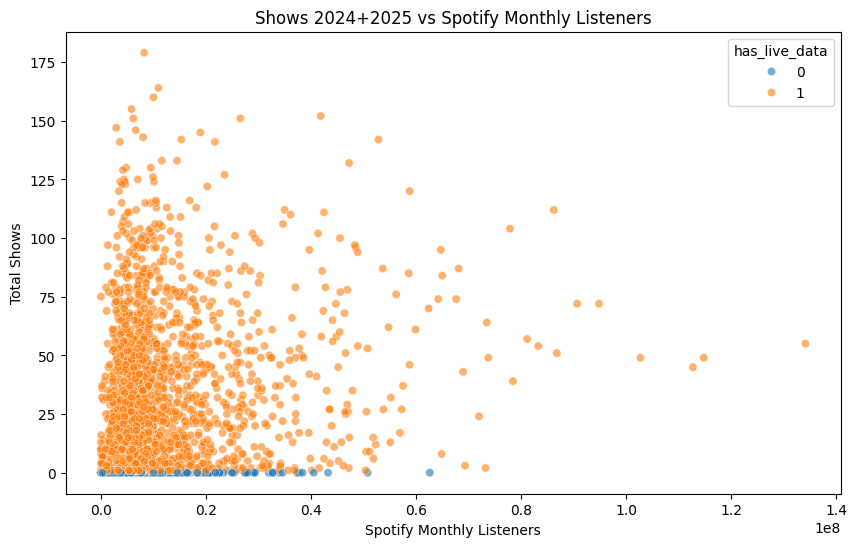

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_select,
    x="sp_monthly_listeners",
    y="n_shows_total",
    hue="has_live_data",
    alpha=0.6
)

plt.xlabel("Spotify Monthly Listeners")
plt.ylabel("Total Shows")
plt.title("Shows 2024+2025 vs Spotify Monthly Listeners")

plt.show()

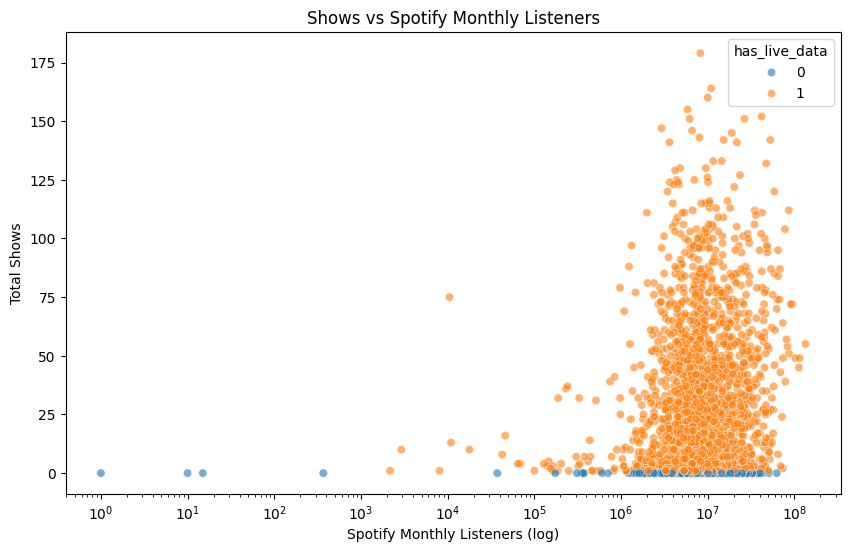

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_select,
    x="sp_monthly_listeners",
    y="n_shows_total",
    hue="has_live_data",
    alpha=0.6
)

plt.xscale("log")

plt.xlabel("Spotify Monthly Listeners (log)")
plt.ylabel("Total Shows")
plt.title("Shows vs Spotify Monthly Listeners")

plt.show()

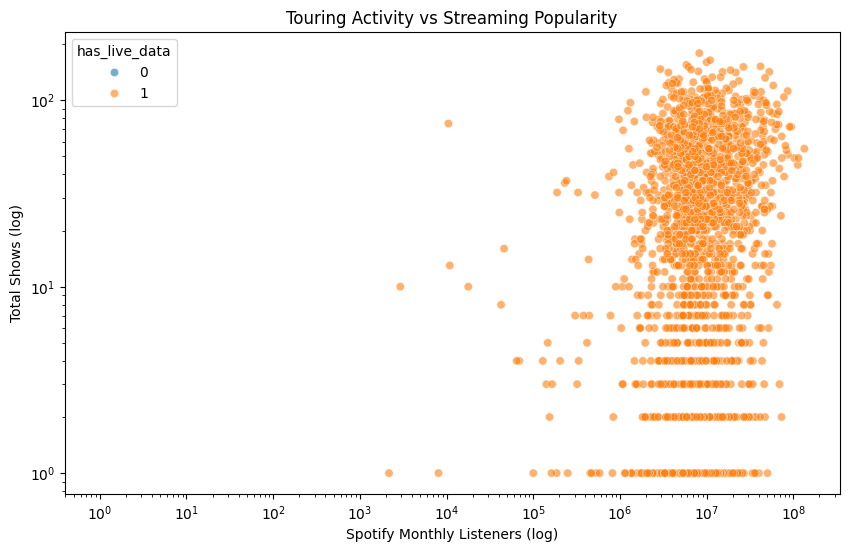

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_select,
    x="sp_monthly_listeners",
    y="n_shows_total",
    hue="has_live_data",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Spotify Monthly Listeners (log)")
plt.ylabel("Total Shows (log)")
plt.title("Touring Activity vs Streaming Popularity")

plt.show()

# FE aparte df_fe

In [ ]:
df_select.shape

(2914, 51)

In [ ]:
df_fe = df_select.copy()
df_fe.shape

(2914, 51)

In [ ]:
import numpy as np

# =========================================================
# 1) live_conversion
# =========================================================

df_fe["live_conversion"] = np.where(
    df_fe["sp_monthly_listeners"] > 0,
    df_fe["n_shows_total"] / df_fe["sp_monthly_listeners"],
    np.nan
)

df_fe["log_live_conversion"] = np.log1p(df_fe["live_conversion"])

# =========================================================
# 2) touring_scale
# =========================================================

df_fe["touring_scale"] = np.where(
    df_fe["n_shows_total"] > 0,
    df_fe["total_capacity_total"] / df_fe["n_shows_total"],
    np.nan
)

df_fe["log_touring_scale"] = np.log1p(df_fe["touring_scale"])

# =========================================================
# 3) dispersión geográfica
# =========================================================

df_fe["tour_spread_countries"] = np.where(
    df_fe["n_shows_total"] > 0,
    df_fe["n_countries_total"] / df_fe["n_shows_total"],
    np.nan
)

df_fe["tour_spread_cities"] = np.where(
    df_fe["n_shows_total"] > 0,
    df_fe["n_cities_total"] / df_fe["n_shows_total"],
    np.nan
)

# =========================================================
# 4) streaming → live capacity
# =========================================================

df_fe["streaming_to_live_capacity"] = np.where(
    df_fe["sp_monthly_listeners"] > 0,
    df_fe["total_capacity_total"] / df_fe["sp_monthly_listeners"],
    np.nan
)

df_fe["log_streaming_to_live_capacity"] = np.log1p(df_fe["streaming_to_live_capacity"])

# =========================================================
# 5) targets continuos
# =========================================================

df_fe["log_n_shows_total"] = np.log1p(df_fe["n_shows_total"])
df_fe["log_total_capacity_total"] = np.log1p(df_fe["total_capacity_total"])



## live status

In [ ]:
import numpy as np

# =========================================================
# 1) live_status
# =========================================================

conditions_status = [
    df_fe["muerto_disuelto"] == True,
    (df_fe["career_stage"] == "legendary") &
    (df_fe["n_shows_total"].isna()) &
    (df_fe["muerto_disuelto"] == False),
    df_fe["n_shows_total"] > 0,
    df_fe["n_shows_total"].isna()
]

choices_status = [
    "muerto_disuelto",
    "off_cycle",
    "active_live",
    "sin_datos_live"
]

df_fe["live_status"] = np.select(conditions_status, choices_status, default="otro")



In [ ]:
df_fe.groupby("live_status").agg(
    artistas=("chartmetric_id", "count"),
    total_shows=("n_shows_total", "sum"),
    shows_promedio=("n_shows_total", "mean")
).sort_values("total_shows", ascending=False)

,artistas,total_shows,shows_promedio
live_status,,,
active_live,1887,62300.0,33.015368
muerto_disuelto,274,0.0,0.000000
off_cycle,39,0.0,NaN
sin_datos_live,714,0.0,NaN


In [ ]:
df_fe["live_status"].value_counts(dropna=False)

live_status
active_live        1887
sin_datos_live      714
muerto_disuelto     274
off_cycle            39
Name: count, dtype: int64

In [ ]:
tabla = df_fe.groupby("live_status").agg(
    artistas=("chartmetric_id","count"),
    total_shows=("n_shows_total","sum")
)

tabla["prop_artistas"] = tabla["artistas"] / tabla["artistas"].sum()
tabla["prop_shows"] = tabla["total_shows"] / tabla["total_shows"].sum()

tabla.sort_values("total_shows", ascending=False)

,artistas,total_shows,prop_artistas,prop_shows
live_status,,,,
active_live,1887,62300.0,0.647563,1.0
muerto_disuelto,274,0.0,0.094029,0.0
off_cycle,39,0.0,0.013384,0.0
sin_datos_live,714,0.0,0.245024,0.0


## life _intensity

In [ ]:
import csv
from pathlib import Path
from collections import defaultdict

INPUT_SUMMARY = Path("chartmetric_liveevents_2024_2025_cohorte2/liveevents_2024_2025_summary_cohorte2.csv")

def to_int(value, default=0):
    try:
        return int(float(str(value).strip()))
    except:
        return default

if not INPUT_SUMMARY.exists():
    raise FileNotFoundError(f"No existe el archivo: {INPUT_SUMMARY}")

with open(INPUT_SUMMARY, "r", encoding="utf-8-sig", newline="") as f:
    rows = list(csv.DictReader(f))

if not rows:
    raise ValueError("El summary está vacío.")

rows_by_id = defaultdict(list)

for row in rows:
    cmid = to_int(row.get("chartmetric_id", ""))
    if cmid:
        rows_by_id[cmid].append(row)

duplicates = {cmid: group for cmid, group in rows_by_id.items() if len(group) > 1}

total_ids = len(rows_by_id)
total_duplicates = sum(len(group) - 1 for group in duplicates.values())

print("=== DETECCIÓN DE DUPLICADOS ===")
print("Archivo:", INPUT_SUMMARY)
print("Filas totales:", len(rows))
print("IDs únicos:", total_ids)
print("Duplicados totales:", total_duplicates)
print("Artistas con duplicados:", len(duplicates))

if not duplicates:
    print("\nNo se detectaron duplicados.")
else:
    print("\nPrimeros 20 artistas con duplicados:")
    for cmid, group in list(duplicates.items())[:20]:
        print(f"{cmid} | repeticiones: {len(group)} | artist_name: {group[-1].get('artist_name', '')}")

=== DETECCIÓN DE DUPLICADOS ===
Archivo: chartmetric_liveevents_2024_2025_cohorte2\liveevents_2024_2025_summary_cohorte2.csv
Filas totales: 2506
IDs únicos: 2506
Duplicados totales: 0
Artistas con duplicados: 0

No se detectaron duplicados.


In [ ]:
print("live_status")
display(df_fe["live_status"].value_counts(dropna=False))

print("\nlive_intensity")
display(df_fe["live_intensity"].value_counts(dropna=False))

live_status


live_status
active_live        1887
sin_datos_live      714
muerto_disuelto     274
off_cycle            39
Name: count, dtype: int64


live_intensity


KeyError: 'live_intensity'

In [ ]:
df_fe["live_status"] = np.select(
    [
        df_fe["muerto_disuelto"] == True,
        (df_fe["career_stage"] == "legendary") &
        (df_fe["n_shows_total"].isna()) &
        (df_fe["muerto_disuelto"] == False),
        df_fe["n_shows_total"] > 0
    ],
    [
        "muerto_disuelto",
        "off_cycle",
        "active_live"
    ],
    default=np.nan
)

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

In [ ]:
import csv
from collections import defaultdict

SUMMARY_FILE = "chartmetric_liveevents_2024_2025_cohorte2/liveevents_2024_2025_summary_cohorte2.csv"

def to_int(value, default=0):
    try:
        return int(float(str(value).strip()))
    except:
        return default

# Leer filas
with open(SUMMARY_FILE, "r", encoding="utf-8-sig", newline="") as f:
    rows = list(csv.DictReader(f))

# Agrupar por chartmetric_id
rows_by_id = defaultdict(list)

for row in rows:
    cmid = to_int(row.get("chartmetric_id", ""))
    if cmid:
        rows_by_id[cmid].append(row)

# Detectar duplicados
duplicates = {k: v for k, v in rows_by_id.items() if len(v) > 1}

print("=== DUPLICADOS DETECTADOS COHORTE2 ===")
print("Cantidad de artistas duplicados:", len(duplicates))
print()

# Mostrar detalle
for cmid, group in duplicates.items():
    print("======================================")
    print(f"chartmetric_id: {cmid}")
    print(f"repeticiones: {len(group)}")
    
    for i, row in enumerate(group, start=1):
        print(f"\n--- fila {i} ---")
        print("artist_name:", row.get("artist_name"))
        print("ok:", row.get("ok"))
        print("status_code:", row.get("status_code"))
        print("n_shows_2024:", row.get("n_shows_2024"))
        print("n_shows_2025:", row.get("n_shows_2025"))
        print("n_requests:", row.get("n_requests_live_2024_2025"))
        print("downloaded_at:", row.get("downloaded_at_utc"))
    
    print()

=== DUPLICADOS DETECTADOS COHORTE2 ===
Cantidad de artistas duplicados: 0



## limpio filas duplicadas live

In [ ]:
import csv
from pathlib import Path
from datetime import datetime

INPUT_SUMMARY = Path("chartmetric_liveevents_2024_2025_cohorte2/liveevents_2024_2025_summary_cohorte2.csv")
OUTPUT_SUMMARY = Path("chartmetric_liveevents_2024_2025_cohorte2/liveevents_2024_2025_summary_dedup_cohorte2.csv")

def to_int(value, default=0):
    try:
        return int(float(str(value).strip()))
    except:
        return default

def count_unique_ids(rows, id_col="chartmetric_id"):
    ids = []
    for row in rows:
        cmid = to_int(row.get(id_col, ""))
        if cmid:
            ids.append(cmid)
    return len(set(ids)), len(ids) - len(set(ids))

if not INPUT_SUMMARY.exists():
    raise FileNotFoundError(f"No existe el archivo de entrada: {INPUT_SUMMARY}")

with open(INPUT_SUMMARY, "r", encoding="utf-8-sig", newline="") as f:
    rows = list(csv.DictReader(f))

if not rows:
    raise ValueError("El summary está vacío.")

fieldnames = list(rows[0].keys())

latest_by_id = {}
for row in rows:
    cmid = to_int(row.get("chartmetric_id", ""))
    if cmid:
        latest_by_id[cmid] = row

dedup_rows = list(latest_by_id.values())

if not dedup_rows:
    raise ValueError("La deduplicación produjo 0 filas. Proceso cancelado.")

with open(OUTPUT_SUMMARY, "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(dedup_rows)

with open(OUTPUT_SUMMARY, "r", encoding="utf-8-sig", newline="") as f:
    check_rows = list(csv.DictReader(f))

if not check_rows:
    raise ValueError("El archivo deduplicado se escribió vacío. Proceso cancelado.")

unique_ids_before, dup_before = count_unique_ids(rows)
unique_ids_after, dup_after = count_unique_ids(check_rows)

print("=== LIMPIEZA SUMMARY ===")
print("Filas originales:", len(rows))
print("IDs únicos originales:", unique_ids_before)
print("Duplicados originales:", dup_before)
print("Filas deduplicadas:", len(check_rows))
print("IDs únicos deduplicados:", unique_ids_after)
print("Duplicados deduplicados:", dup_after)
print("Archivo deduplicado creado:", OUTPUT_SUMMARY)

if dup_after != 0:
    raise ValueError("El archivo deduplicado todavía tiene duplicados. Proceso cancelado.")

=== LIMPIEZA SUMMARY ===
Filas originales: 2500
IDs únicos originales: 2500
Duplicados originales: 0
Filas deduplicadas: 2500
IDs únicos deduplicados: 2500
Duplicados deduplicados: 0
Archivo deduplicado creado: chartmetric_liveevents_2024_2025_cohorte2\liveevents_2024_2025_summary_dedup_cohorte2.csv


## reasigno filenames

In [ ]:
import shutil
from pathlib import Path
from datetime import datetime
import csv

BASE_DIR = Path("chartmetric_liveevents_2024_2025_cohorte2")

original = BASE_DIR / "liveevents_2024_2025_summary_cohorte2.csv"
dedup = BASE_DIR / "liveevents_2024_2025_summary_dedup_cohorte2.csv"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
backup = BASE_DIR / f"liveevents_2024_2025_summary_backup_{timestamp}_cohorte2.csv"

def count_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        rows = list(csv.DictReader(f))
    return len(rows)

if not dedup.exists():
    raise FileNotFoundError(f"No existe el archivo deduplicado: {dedup}")

dedup_rows = count_rows(dedup)
if dedup_rows == 0:
    raise ValueError("El archivo deduplicado está vacío. Reemplazo cancelado.")

if original.exists():
    shutil.copy2(original, backup)
    print("Backup creado:", backup.name)
else:
    print("No existe archivo original. El deduplicado pasará a ser el oficial sin backup previo.")

shutil.copy2(dedup, original)
print("Archivo deduplicado copiado como oficial:", original.name)

final_rows = count_rows(original)
if final_rows != dedup_rows:
    raise ValueError(
        f"Verificación fallida: original final={final_rows}, dedup={dedup_rows}. "
        "El backup quedó disponible para recuperación."
    )

print("=== REEMPLAZO COMPLETADO ===")
print("Filas en dedup:", dedup_rows)
print("Filas en original final:", final_rows)
print("Proceso terminado.")

Archivo de backup previo eliminado para dejar espacio.
Original (con duplicados) renombrado a: liveevents_2024_2025_summary_condup_cohorte2.csv
No se encontró el archivo liveevents_2024_2025_summary_dedup_cohorte2.csv. Revisa si el nombre es correcto.

Proceso terminado.


In [ ]:
df_fe["n_shows_total"].describe()

count    2161.000000
mean       28.829246
std        31.565643
min         0.000000
25%         3.000000
50%        18.000000
75%        46.000000
max       179.000000
Name: n_shows_total, dtype: float64

## GRAFICOS

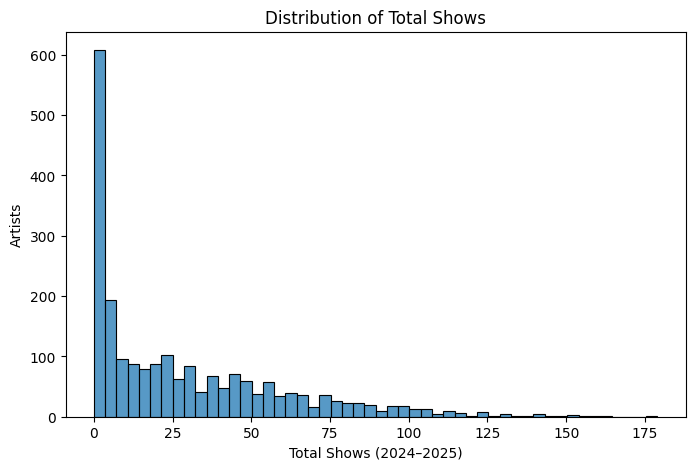

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df_select["n_shows_total"], bins=50)

plt.xlabel("Total Shows (2024–2025)")
plt.ylabel("Artists")
plt.title("Distribution of Total Shows")

plt.show()

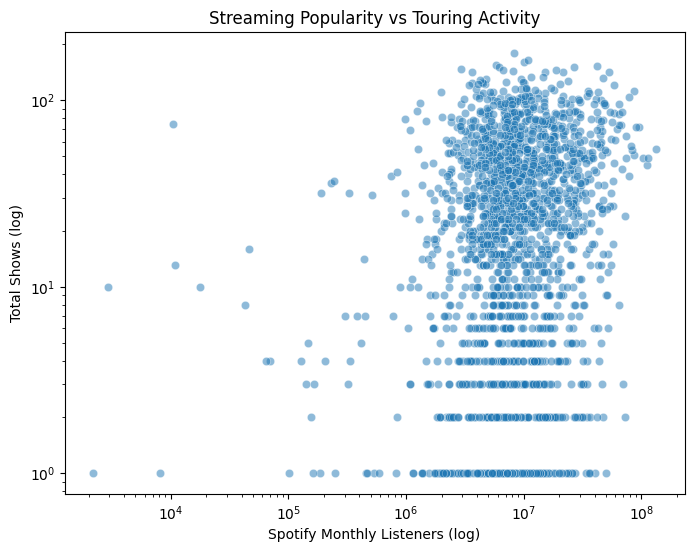

In [ ]:
df_plot = df_select[
    (df_select["sp_monthly_listeners"] > 0) &
    (df_select["n_shows_total"] > 0)
]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_plot,
    x="sp_monthly_listeners",
    y="n_shows_total",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Spotify Monthly Listeners (log)")
plt.ylabel("Total Shows (log)")
plt.title("Streaming Popularity vs Touring Activity")

plt.show()

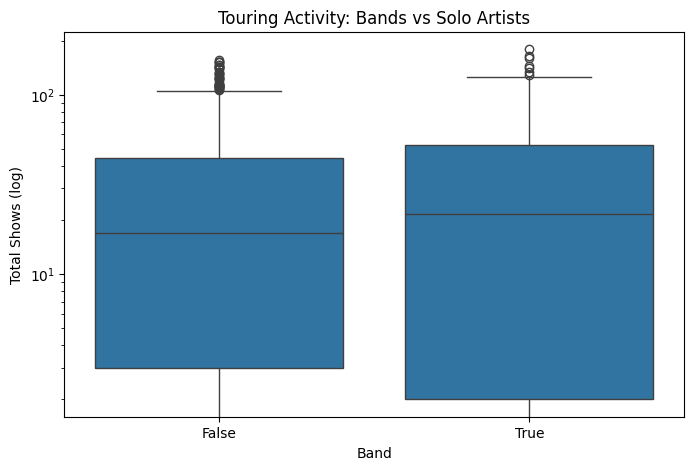

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_select,
    x="band",
    y="n_shows_total"
)

plt.yscale("log")

plt.xlabel("Band")
plt.ylabel("Total Shows (log)")
plt.title("Touring Activity: Bands vs Solo Artists")

plt.show()

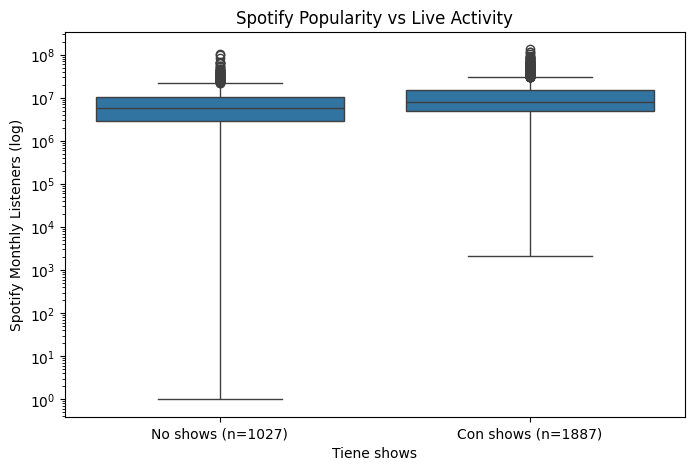

In [ ]:
df_plot = df_select.copy()

df_plot["tiene_shows"] = df_plot["n_shows_total"] > 0
df_plot["tiene_shows"] = df_plot["tiene_shows"].fillna(False)

# conteos
counts = df_plot["tiene_shows"].value_counts()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_plot,
    x="tiene_shows",
    y="sp_monthly_listeners"
)

plt.yscale("log")

plt.xlabel("Tiene shows")
plt.ylabel("Spotify Monthly Listeners (log)")
plt.title("Spotify Popularity vs Live Activity")

# labels con n
plt.xticks(
    [0,1],
    [f"No shows (n={counts[False]})", f"Con shows (n={counts[True]})"]
)

plt.show()

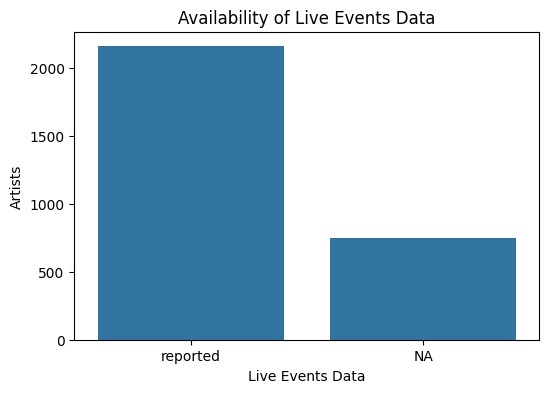

shows_status
reported    2161
NA           753
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_select["shows_status"] = df_select["n_shows_total"].apply(
    lambda x: "NA" if pd.isna(x) else "reported"
)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_select,
    x="shows_status"
)

plt.xlabel("Live Events Data")
plt.ylabel("Artists")
plt.title("Availability of Live Events Data")

plt.show()

print(df_select["shows_status"].value_counts(dropna=False))

career_stage
superstar     482
mainstream    231
legendary      39
mid-level       1
Name: count, dtype: int64


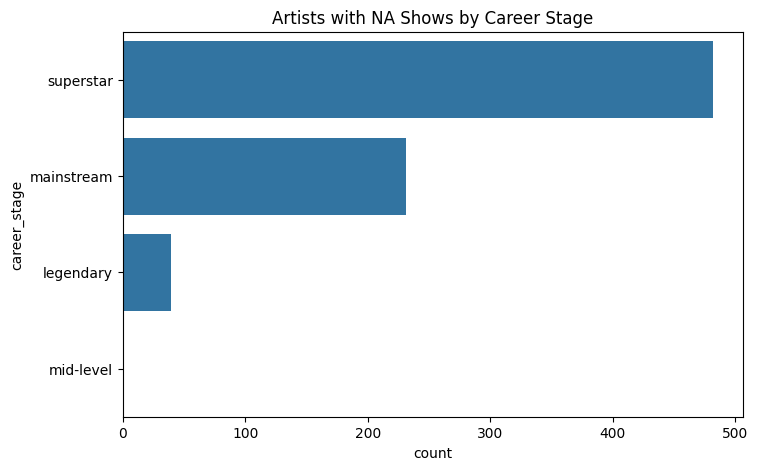

In [ ]:
df_nan = df_select[df_select["n_shows_total"].isna()]

career_nan = (
    df_nan["career_stage"]
    .value_counts()
)

print(career_nan)
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_nan,
    y="career_stage",
    order=df_nan["career_stage"].value_counts().index
)

plt.title("Artists with NA Shows by Career Stage")

plt.show()

In [ ]:
df_nan_rank = df_select[df_select["n_shows_total"].isna()]

print(df_nan_rank["cm_artist_rank"].describe())

count       753.000000
mean       3752.560425
std        9351.749526
min           3.000000
25%        1345.000000
50%        2483.000000
75%        3607.000000
max      127239.000000
Name: cm_artist_rank, dtype: float64


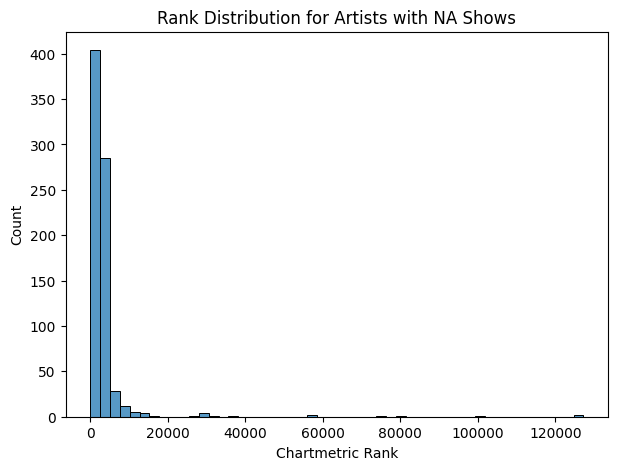

In [ ]:
plt.figure(figsize=(7,5))

sns.histplot(
    df_nan_rank["cm_artist_rank"],
    bins=50
)

plt.xlabel("Chartmetric Rank")
plt.title("Rank Distribution for Artists with NA Shows")

plt.show()

In [ ]:
df_nan = df_select[df_select["n_shows_total"].isna()]

print(
    df_nan["muerto_disuelto"].value_counts(dropna=False)
)

muerto_disuelto
False    753
Name: count, dtype: int64


In [ ]:
pd.crosstab(
    df_nan["career_stage"],
    df_nan["muerto_disuelto"],
    margins=True
)

muerto_disuelto,False,All
career_stage,,
legendary,39,39
mainstream,231,231
mid-level,1,1
superstar,482,482
All,753,753


In [ ]:
df_plot = df_fe[
    (df_fe["live_intensity"].notna()) &
    (df_fe["muerto_disuelto"] == False)
]

pd.crosstab(
    df_plot["career_stage"],
    df_plot["live_intensity"]
)

live_profile,actividad_media,alta_actividad,pocos_shows,sin_datos_live
career_stage,,,,
developing,0,0,1,0
legendary,100,18,80,39
mainstream,138,14,207,231
mid-level,0,0,1,1
superstar,615,47,666,482


In [ ]:
pd.crosstab(
    df_plot["career_stage"],
    df_plot["live_intensity"],
    normalize="index"
) * 100

live_profile,actividad_media,alta_actividad,pocos_shows,sin_datos_live
career_stage,,,,
developing,0.000000,0.000000,100.000000,0.000000
legendary,42.194093,7.594937,33.755274,16.455696
mainstream,23.389831,2.372881,35.084746,39.152542
mid-level,0.000000,0.000000,50.000000,50.000000
superstar,33.977901,2.596685,36.795580,26.629834


In [ ]:
df_plot = df_fe[
    (df_fe["live_intensity"].notna()) &
    (df_fe["muerto_disuelto"] == False)
]

tabla = pd.crosstab(
    df_plot["career_stage"],
    df_plot["live_intensity"]
)

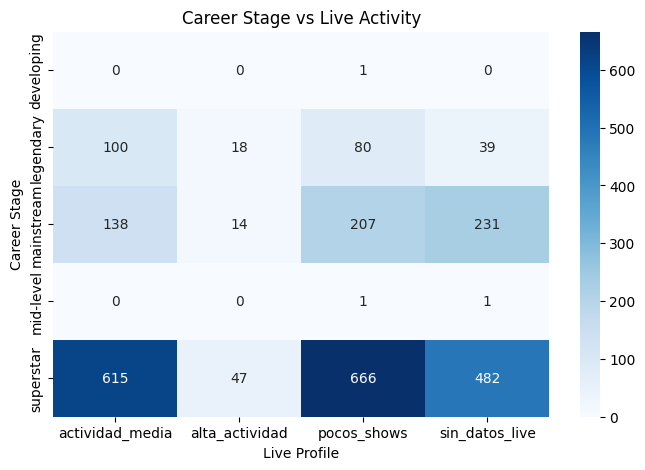

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    tabla,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Live Profile")
plt.ylabel("Career Stage")
plt.title("Career Stage vs Live Activity")

plt.show()

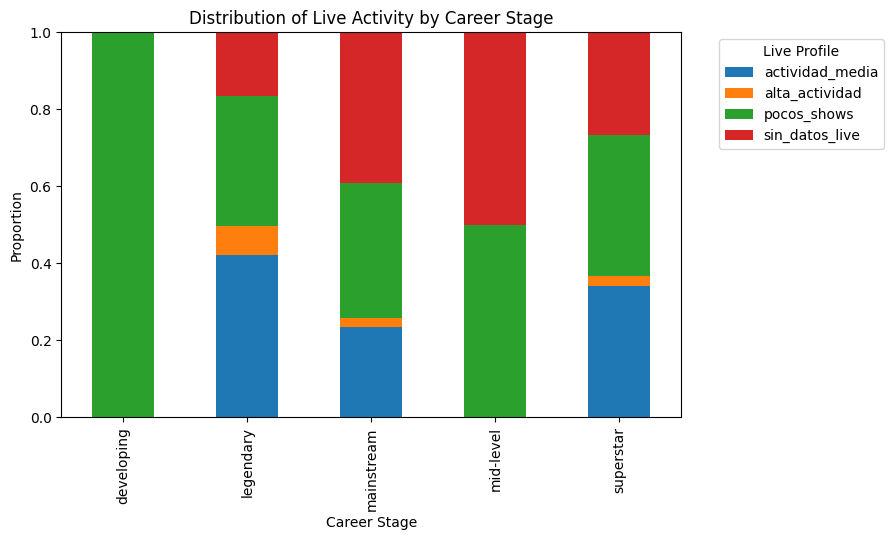

In [ ]:
tabla_prop = pd.crosstab(
    df_plot["career_stage"],
    df_plot["live_intensity"],
    normalize="index"
)

tabla_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Proportion")
plt.xlabel("Career Stage")
plt.title("Distribution of Live Activity by Career Stage")

plt.legend(title="Live Profile", bbox_to_anchor=(1.05,1))

plt.show()